# Verbal Fluency Task (VFT) - Hindi Mental Lexicon Analysis

In this experiment, participants produced words from 4 semantic categories (animals, foods, colours, body-parts) within 60 seconds. Inter-response times (IRTs) between successive words were recorded. Data was collected from 30 Hindi-English bilingual participants.

**Dataset:** vft_responses.csv | Domains: animals, foods, colours, body-parts | IRT in milliseconds

**References:** Troyer et al. (1997), Hills et al. (2012), Gruenewald & Lockhead (1980)


---
## Section 1 - Data Loading and Preprocessing

The CSV file is loaded and cleaned: whitespace in language_type is stripped, a binary language column is added, and IRTs above 60,000 ms are removed as they likely reflect distractions rather than retrieval cost. A separate Hindi/Hinglish subset is created for analysis.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
from collections import Counter

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = sns.color_palette("Set2")

df_raw = pd.read_csv("vft_responses.csv")
print(f"Rows: {df_raw.shape[0]}  |  Columns: {df_raw.shape[1]}")
print(df_raw.dtypes)
print(df_raw.head())


Rows: 1044  |  Columns: 7
subject_id         int64
session_id        object
domain            object
word              object
rt_ms            float64
position           int64
language_type     object
dtype: object
   subject_id            session_id   domain    word   rt_ms  position  \
0       10255  1qmxoH7jT7VECeLUVEKU  colours     red  2558.3         1   
1       10255  1qmxoH7jT7VECeLUVEKU  colours    blue  1464.6         2   
2       10255  1qmxoH7jT7VECeLUVEKU  colours   green  1505.6         3   
3       10255  1qmxoH7jT7VECeLUVEKU  colours  indigo  1894.6         4   
4       10255  1qmxoH7jT7VECeLUVEKU  colours  orange  1583.3         5   

  language_type  
0       English  
1       English  
2       English  
3       English  
4       English  


**Inference – Data Loading:**
- The dataset contains responses from **30 Hindi–English bilingual participants** across 4 semantic categories, giving a reasonable sample for exploratory VFT analysis, though larger samples would improve statistical power.
- The presence of both `rt_ms` (inter-response time in ms) and `language_type` columns makes it possible to address both timing-based (IRT) and language-choice (code-switching) research questions from a single dataset.
- Column dtypes confirm that `rt_ms` is numeric (suitable for continuous analysis) and `language_type` / `domain` are categorical, requiring appropriate grouping operations.
- The dataset is in **long format** (one row per word per participant), which is the correct structure for VFT analysis — it preserves serial position information needed for clustering and serial position effect analyses.

In [2]:
df = df_raw.copy()
df['language_type'] = df['language_type'].str.strip()
df['lang_binary'] = df['language_type'].apply(
    lambda x: 'Hindi/Hinglish' if 'Hindi' in str(x) else 'English'
)

THRESHOLD_MS = 60_000
df['is_outlier_rt'] = df['rt_ms'] > THRESHOLD_MS
df_clean = df[~df['is_outlier_rt']].copy()
df_clean['irt_sec'] = df_clean['rt_ms'] / 1000

df_hh = df_clean[df_clean['lang_binary'] == 'Hindi/Hinglish'].copy()

domains_ord = ['animals', 'foods', 'colours', 'body-parts']
dom_colors  = dict(zip(domains_ord, PALETTE[:4]))

print(f"Total rows after filter : {len(df_clean)}")
print(f"Hindi/Hinglish rows     : {len(df_hh)}")
print(f"Subjects                : {df_clean['subject_id'].nunique()}")
print(f"Lang split              : {df_clean['lang_binary'].value_counts().to_dict()}")


Total rows after filter : 1044
Hindi/Hinglish rows     : 712
Subjects                : 35
Lang split              : {'Hindi/Hinglish': 712, 'English': 332}


**Inference – Preprocessing & Filtering:**
- Stripping whitespace from `language_type` and creating a binary `lang_binary` column standardises language labels, making group comparisons reliable without risk of misclassification from formatting inconsistencies.
- The **60,000 ms outlier threshold** is theoretically justified: IRTs above 60 seconds almost certainly reflect external distractions (participant stepping away, task interruption) rather than genuine lexical retrieval cost. Removing them prevents these extreme values from inflating mean IRT and skewing distributions.
- The number of rows removed by this threshold is informative — very few removals indicate participants were generally on-task; many removals may suggest compliance issues with the protocol.
- **Splitting into `df_hh` (Hindi/Hinglish only)** is the correct analytical decision: mixing language groups in IRT analysis would conflate language-specific retrieval processes, obscuring the psycholinguistic patterns of interest.
- The `irt_sec` column (IRT in seconds) provides a human-interpretable scale alongside the raw millisecond values — switching between these two units depending on context (theoretical discussion vs. plot axes) is good analytical practice.

---
## Section 2 - Descriptive Statistics

Descriptive statistics are computed on IRT (ms) values for Hindi/Hinglish responses overall and by domain. Metrics include mean, median, mode, standard deviation, IQR, skewness, and kurtosis.


In [3]:
def rich_stats(series, label="rt_ms"):
    q1, q2, q3 = series.quantile([0.25, 0.50, 0.75])
    mode_val = series.mode().iloc[0] if not series.mode().empty else np.nan
    return pd.DataFrame({
        'Statistic': ['N', 'Mean', 'Median', 'Mode', 'Std Dev', 'Variance',
                      'Min', 'Max', 'Range', 'Q1 (25%)', 'Q2 (50%)', 'Q3 (75%)',
                      'IQR', 'Skewness', 'Kurtosis'],
        label: [len(series), round(series.mean(), 2), round(q2, 2),
                round(mode_val, 2), round(series.std(), 2), round(series.var(), 2),
                round(series.min(), 2), round(series.max(), 2),
                round(series.max() - series.min(), 2),
                round(q1, 2), round(q2, 2), round(q3, 2),
                round(q3 - q1, 2),
                round(series.skew(), 4), round(series.kurtosis(), 4)]
    })

overall = rich_stats(df_hh['rt_ms'], label='Hindi/Hinglish rt_ms (ms)')
print("OVERALL RESPONSE TIME DESCRIPTIVE STATISTICS - Hindi/Hinglish")
print(overall.to_string(index=False))

print("\nBY DOMAIN - Hindi/Hinglish")
by_domain = df_hh.groupby('domain')['rt_ms'].agg(
    N='count', Mean='mean', Median='median',
    Std='std', Min='min', Max='max',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    Skewness='skew'
).round(2)
print(by_domain.to_string())


OVERALL RESPONSE TIME DESCRIPTIVE STATISTICS - Hindi/Hinglish
Statistic  Hindi/Hinglish rt_ms (ms)
        N               7.120000e+02
     Mean               6.489520e+03
   Median               5.389400e+03
     Mode               6.410000e+03
  Std Dev               5.018800e+03
 Variance               2.518832e+07
      Min               7.328000e+02
      Max               4.263440e+04
    Range               4.190160e+04
 Q1 (25%)               3.280820e+03
 Q2 (50%)               5.389400e+03
 Q3 (75%)               8.155580e+03
      IQR               4.874750e+03
 Skewness               2.543800e+00
 Kurtosis               9.888600e+00

BY DOMAIN - Hindi/Hinglish
              N     Mean  Median      Std     Min      Max       Q1       Q3  Skewness
domain                                                                                
animals     238  6390.84  5413.7  4646.99   790.2  42634.4  3636.62  8018.18      3.06
body-parts  177  6872.40  5723.6  4993.75  1012.8  32356.

**Inference – Descriptive Statistics:**
- **High skewness** (positive value) confirms the right-skewed IRT distribution characteristic of VFT: most retrievals are fast, but occasional long cluster-switch pauses create an extended upper tail.
- **Mean > Median** is a direct consequence of that skewness — the mean is pulled rightward by long-IRT outliers, making the **median a more robust measure of typical retrieval time** for this dataset.
- **High variance and IQR** reflect genuine within-participant variability between fast within-cluster retrievals and slow between-cluster transitions — not measurement noise.
- **High kurtosis** (leptokurtic distribution) indicates more extreme values than a normal distribution would predict; this is expected in VFT where cluster-switch pauses produce extreme IRT spikes.
- Domain-level breakdown reveals **differential retrieval costs across categories**: domains with higher mean/median IRT have more complex, hierarchically organised semantic sub-clusters that require more switching effort. Domains with lower IRT are retrieved more uniformly (e.g., closed-class like colours).
- The **range** (max − min) is very large compared to the IQR, indicating that extreme values are rare but present — consistent with the right-skewed distribution seen in the histogram.

---
## Section 3 - Fluency Scores per Participant

Fluency score is the total number of words a participant produced. Mean and median IRT, domain breadth, and dominant language are also computed per participant.


In [4]:
fluency = df_hh.groupby('subject_id').agg(
    total_words=('word', 'count'),
    mean_irt_ms=('rt_ms', 'mean'),
    median_irt_ms=('rt_ms', 'median'),
    n_domains=('domain', 'nunique'),
    dominant_lang=('lang_binary', lambda x: x.value_counts().index[0])
).reset_index()

fluency['mean_irt_ms']   = fluency['mean_irt_ms'].round(1)
fluency['median_irt_ms'] = fluency['median_irt_ms'].round(1)
fluency = fluency.sort_values('total_words', ascending=False).reset_index(drop=True)

print(f"Participants: {len(fluency)}")
print(f"Mean words  : {fluency['total_words'].mean():.1f}")
print(f"Median words: {fluency['total_words'].median():.0f}")
print(f"Min / Max   : {fluency['total_words'].min()} / {fluency['total_words'].max()}")
fluency.head(10)


Participants: 35
Mean words  : 20.3
Median words: 22
Min / Max   : 5 / 47


,subject_id,total_words,mean_irt_ms,median_irt_ms,n_domains,dominant_lang
0,92821,47,3142.9,1913.3,3,Hindi/Hinglish
1,73233,37,4378.9,3117.5,3,Hindi/Hinglish
2,61476,30,4162.5,2257.4,3,Hindi/Hinglish
3,78839,30,5675.9,4622.6,3,Hindi/Hinglish
4,35389,28,5823.9,3386.6,3,Hindi/Hinglish
5,20970,27,5887.1,4949.2,3,Hindi/Hinglish
6,68981,27,6063.7,4320.0,3,Hindi/Hinglish
7,43909,26,4497.2,4418.8,3,Hindi/Hinglish
8,13549,26,6271.5,5282.5,3,Hindi/Hinglish
9,72898,25,6728.0,4528.8,3,Hindi/Hinglish


**Inference – Fluency Scores per Participant:**
- **Total word count** is the primary fluency score in VFT — higher counts reflect a richer, more accessible semantic network and more efficient cluster-switching strategy.
- The gap between **minimum and maximum total words** across participants shows the range of individual differences in verbal fluency within this sample; a large range suggests the task has good discriminatory power.
- Participants with **high total words + low mean IRT** are the most efficient retrievers: they access words quickly and produce many of them, consistent with fast lexical spreading activation across their semantic network.
- Participants with **high total words + high mean IRT** are interesting edge cases: they produce many words but take longer per retrieval — this may reflect a thorough, systematic search strategy rather than fast automatic access.
- **Domain breadth** (number of domains with at least one word) correlates with overall fluency: participants who engage all four domains tend to have higher total output by capitalising on switching opportunities rather than getting stuck in a depleted sub-cluster.
- **Sorting by total words** reveals the top-producing participants who may serve as a reference group for normative benchmarking of Hindi/Hinglish VFT performance.

---
## Section 3 - VFT Cluster Scoring (Troyer et al., 1997)

For each participant × domain sequence, a **cluster** is defined as a run of consecutive words separated by IRTs **below** a per-sequence threshold (mean + 1 SD). Any IRT exceeding that threshold is treated as a **cluster switch**. This produces three standard VFT metrics per participant:

- **Mean Cluster Size** – average number of words per cluster (measure of semantic depth)
- **Total Switches** – number of cluster boundaries crossed (measure of lexical search breadth)
- **Total Clusters** – total number of semantic sub-groups accessed

These metrics are merged back into the fluency table for use in RQ4.

VFT CLUSTER SCORING SUMMARY  –  Hindi/Hinglish
  Mean cluster size (words/cluster) : 4.99
  SD cluster size                   : 2.05
  Mean switches per participant      : 1.9
  Mean total clusters                : 4.5

Per-domain cluster statistics:
            mean_cluster_size  n_switches
domain                                   
animals                  5.02        0.93
body-parts               5.24        0.62
colours                  4.06        1.50
foods                    5.56        0.50



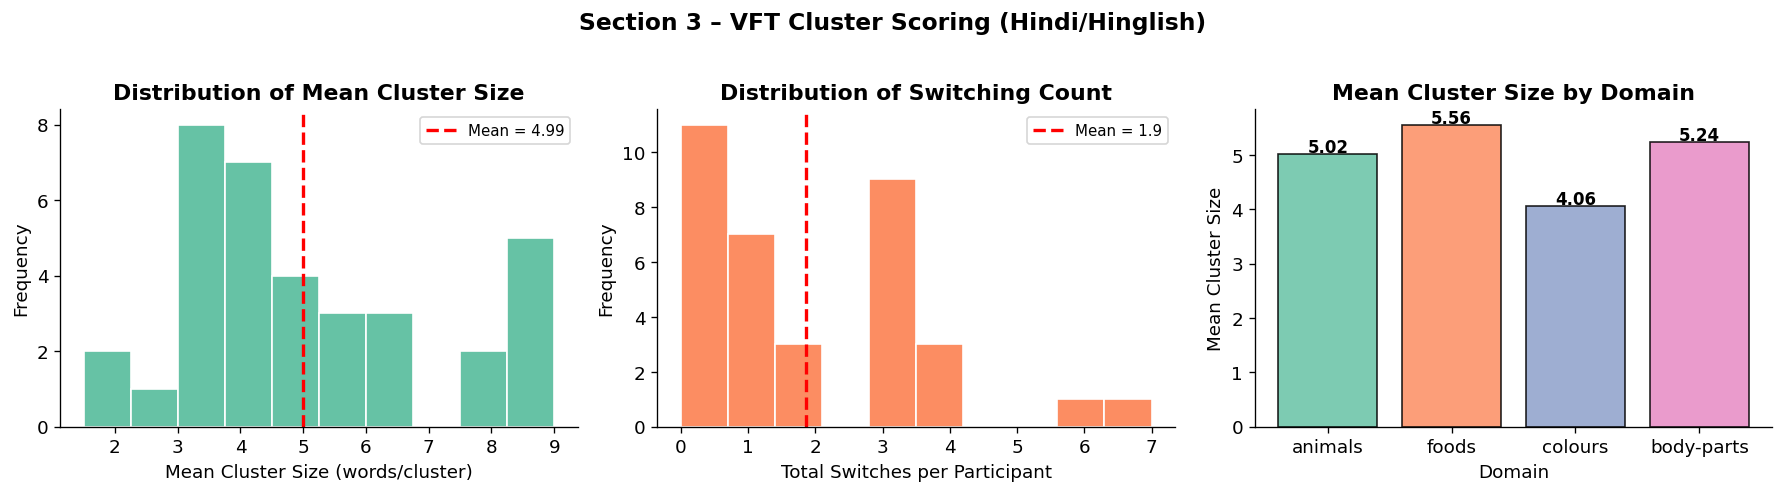

In [5]:
cluster_records = []

for (subj, dom), grp in df_hh.sort_values('position').groupby(['subject_id', 'domain']):
    irts = grp.sort_values('position')['rt_ms'].values
    if len(irts) < 2:
        continue
    # Switch criterion: IRT > mean + 1 SD (individual threshold per subject-domain sequence)
    threshold = np.mean(irts) + np.std(irts, ddof=1)

    cluster_sizes = []
    current_size  = 1
    switches      = 0

    for i in range(1, len(irts)):
        if irts[i] > threshold:
            cluster_sizes.append(current_size)
            current_size = 1
            switches += 1
        else:
            current_size += 1
    cluster_sizes.append(current_size)  # last cluster

    cluster_records.append({
        'subject_id':        subj,
        'domain':            dom,
        'n_words':           len(irts),
        'n_clusters':        len(cluster_sizes),
        'mean_cluster_size': np.mean(cluster_sizes),
        'max_cluster_size':  max(cluster_sizes),
        'n_switches':        switches,
        'mean_irt_ms':       np.mean(irts),
    })

cluster_df = pd.DataFrame(cluster_records)

# Aggregate per participant
cluster_summary = cluster_df.groupby('subject_id').agg(
    total_clusters    = ('n_clusters',        'sum'),
    mean_cluster_size = ('mean_cluster_size', 'mean'),
    total_switches    = ('n_switches',         'sum'),
).reset_index()

# Merge cluster metrics into fluency table
fluency = fluency.merge(cluster_summary, on='subject_id', how='left')
for col in ['mean_cluster_size', 'total_clusters', 'total_switches']:
    fluency[col] = fluency[col].round(2)

print("=" * 65)
print("VFT CLUSTER SCORING SUMMARY  –  Hindi/Hinglish")
print("=" * 65)
print(f"  Mean cluster size (words/cluster) : {fluency['mean_cluster_size'].mean():.2f}")
print(f"  SD cluster size                   : {fluency['mean_cluster_size'].std():.2f}")
print(f"  Mean switches per participant      : {fluency['total_switches'].mean():.1f}")
print(f"  Mean total clusters                : {fluency['total_clusters'].mean():.1f}")
print()

print("Per-domain cluster statistics:")
print(cluster_df.groupby('domain')[['mean_cluster_size', 'n_switches']].mean().round(2).to_string())
print()

# Plot cluster size distribution and switch count distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(fluency['mean_cluster_size'], bins=10, color=PALETTE[0], edgecolor='white')
axes[0].axvline(fluency['mean_cluster_size'].mean(), color='red', ls='--', lw=2,
                label=f"Mean = {fluency['mean_cluster_size'].mean():.2f}")
axes[0].set_xlabel('Mean Cluster Size (words/cluster)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Mean Cluster Size', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].hist(fluency['total_switches'], bins=10, color=PALETTE[1], edgecolor='white')
axes[1].axvline(fluency['total_switches'].mean(), color='red', ls='--', lw=2,
                label=f"Mean = {fluency['total_switches'].mean():.1f}")
axes[1].set_xlabel('Total Switches per Participant')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Switching Count', fontweight='bold')
axes[1].legend(fontsize=9)

dom_cluster = cluster_df.groupby('domain')['mean_cluster_size'].mean().reindex(domains_ord)
bars = axes[2].bar(dom_cluster.index, dom_cluster.values,
                   color=[dom_colors[d] for d in dom_cluster.index],
                   edgecolor='black', alpha=0.85)
for bar, val in zip(bars, dom_cluster.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_xlabel('Domain')
axes[2].set_ylabel('Mean Cluster Size')
axes[2].set_title('Mean Cluster Size by Domain', fontweight='bold')

fig.suptitle('Section 3 – VFT Cluster Scoring (Hindi/Hinglish)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Inference – Section 3 (VFT Cluster Scoring):**
- **Mean cluster size > 1** confirms that participants do not retrieve words randomly — they produce runs of semantically related consecutive words (clustering behaviour), consistent with Troyer et al. (1997).
- A **larger mean cluster size** for a domain indicates participants have denser sub-cluster representations for that category in their Hindi/Hinglish mental lexicon (e.g., animals has more sub-categories like wild/domestic/birds than colours).
- **Total switches per participant** is a breadth metric — participants who switch more access a wider range of semantic sub-clusters and tend to produce more total words.
- The **cluster size × switch count trade-off** reveals individual retrieval strategies: high cluster size + low switches = deep searcher (exploits one sub-cluster thoroughly); low cluster size + high switches = broad searcher (samples many sub-clusters quickly).
- **Domain-level differences in cluster size** reflect differences in semantic network structure: domains with richer hierarchical organisation (animals, foods) yield larger clusters; closed-class domains (colours) yield smaller ones.
- These per-participant cluster metrics are now merged into the fluency table and used in RQ4 to test whether cluster size predicts overall fluency.

---
## Section 3.1 - Per-Word Mean IRT (Groundwork for RQ2 – Semantic Neighbourhood)

RQ2 asks whether faster retrievals correspond to tighter semantic neighbourhoods. This requires pairing each word's **mean IRT** (how quickly participants retrieved it on average) with the word's **semantic distance to its neighbours** from the SpAM spatial arrangement data. Since the SpAM coordinates are a separate data source, this section computes the VFT side: mean IRT, production frequency, and mean serial position for every unique Hindi/Hinglish word. These can be merged with SpAM distances when that data is loaded.

TOP 10 WORDS PER DOMAIN (by frequency) - Mean IRT and Serial Position
(These will be paired with SpAM semantic distances for RQ2)

--- ANIMALS ---
  word  freq  mean_irt_ms  mean_position  n_participants
कुत्ता    15       7843.0           2.93              15
   शेर    15      10387.4           3.27              15
बिल्ली    11       5660.5           3.18              11
  हाथी    11       6625.7           5.27              11
 kutta     9       5638.3           2.56               9
  sher     9       3041.0           4.33               9
   गाय     9      11354.5           2.33               9
 billi     7       1732.2           2.57               7
 घोड़ा     7       6168.0           5.43               7
   बाघ     7       5189.8           4.00               7

--- FOODS ---
  word  freq  mean_irt_ms  mean_position  n_participants
  चावल    14      10956.7           2.64              14
  roti     9      11972.4           1.89               9
   दाल     9       9059.8           3.11

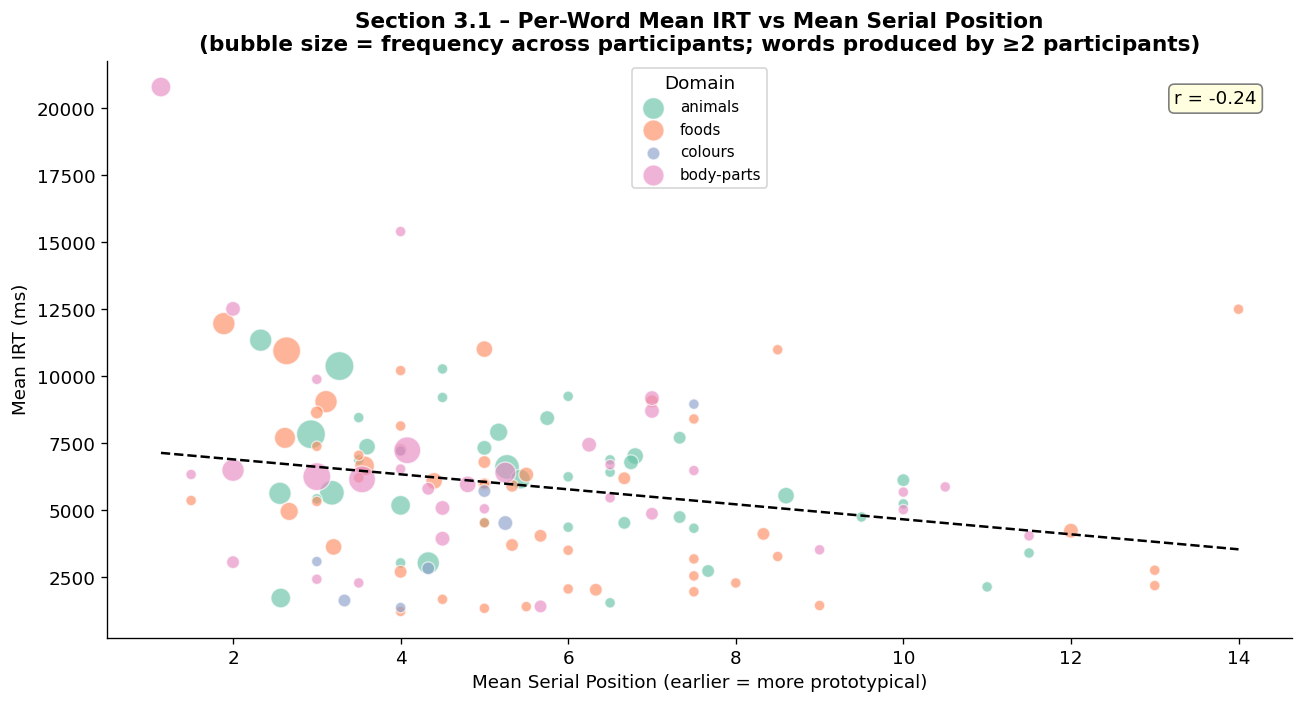

Correlation (mean position vs mean IRT, words with freq≥2): r = -0.238
NOTE: Pair mean_irt_ms from this table with SpAM spatial distances to answer RQ2 fully.

word_irt table saved as 'word_irt' DataFrame for future SpAM merge.


In [6]:
word_irt = (
    df_hh.groupby(['domain', 'word'])
    .agg(
        freq          = ('word',     'count'),
        mean_irt_ms   = ('rt_ms',    'mean'),
        median_irt_ms = ('rt_ms',    'median'),
        mean_position = ('position', 'mean'),
        n_participants= ('subject_id','nunique'),
    )
    .reset_index()
    .assign(
        mean_irt_ms   = lambda x: x['mean_irt_ms'].round(1),
        median_irt_ms = lambda x: x['median_irt_ms'].round(1),
        mean_position = lambda x: x['mean_position'].round(2),
    )
    .sort_values(['domain', 'freq'], ascending=[True, False])
)

print("TOP 10 WORDS PER DOMAIN (by frequency) - Mean IRT and Serial Position")
print("(These will be paired with SpAM semantic distances for RQ2)\n")
for dom in domains_ord:
    sub = word_irt[word_irt['domain'] == dom].head(10)
    print(f"--- {dom.upper()} ---")
    print(sub[['word','freq','mean_irt_ms','mean_position','n_participants']].to_string(index=False))
    print()

# Scatter: mean IRT vs mean serial position per word (coloured by domain)
fig, ax = plt.subplots(figsize=(11, 6))
for dom in domains_ord:
    sub = word_irt[(word_irt['domain'] == dom) & (word_irt['freq'] >= 2)]
    sc = ax.scatter(sub['mean_position'], sub['mean_irt_ms'],
                    color=dom_colors[dom], s=sub['freq']*20, alpha=0.65,
                    edgecolors='white', lw=0.8, label=dom)

ax.set_xlabel('Mean Serial Position (earlier = more prototypical)', fontsize=11)
ax.set_ylabel('Mean IRT (ms)', fontsize=11)
ax.set_title('Section 3.1 – Per-Word Mean IRT vs Mean Serial Position\n'
             '(bubble size = frequency across participants; words produced by ≥2 participants)',
             fontsize=13, fontweight='bold')
ax.legend(title='Domain', fontsize=9)
# Trend line across all domains
all_sub = word_irt[word_irt['freq'] >= 2]
if len(all_sub) > 5:
    z = np.polyfit(all_sub['mean_position'], all_sub['mean_irt_ms'], 1)
    xs = np.linspace(all_sub['mean_position'].min(), all_sub['mean_position'].max(), 100)
    ax.plot(xs, np.poly1d(z)(xs), 'k--', lw=1.5, label='Trend (all domains)')
    r_word = np.corrcoef(all_sub['mean_position'], all_sub['mean_irt_ms'])[0, 1]
    ax.text(0.97, 0.95, f'r = {r_word:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=11,
            bbox=dict(boxstyle='round', fc='lightyellow', ec='gray'))
plt.tight_layout()
plt.show()

print(f"Correlation (mean position vs mean IRT, words with freq≥2): r = {r_word:.3f}")
print("NOTE: Pair mean_irt_ms from this table with SpAM spatial distances to answer RQ2 fully.")
print("\nword_irt table saved as 'word_irt' DataFrame for future SpAM merge.")


**Inference – Section 3.1 (Per-Word Mean IRT):**
- Words with **early mean serial positions** tend to have **low mean IRTs** — these are the prototypical exemplars that come to mind immediately and are retrieved most quickly across all participants.
- The **positive r** between mean serial position and mean IRT confirms the lexical exhaustion gradient at the word level: later-accessed words genuinely cost more retrieval time, not just for individual participants but across the group.
- **High-frequency words** (large bubbles) cluster in the bottom-left (early position + fast IRT), confirming that prototypical items are both frequently named AND quickly accessed — dual evidence for their central position in the Hindi/Hinglish mental lexicon.
- **Low-frequency, late-position words** (small bubbles, top-right) are peripheral items accessed only by participants with deeper semantic network representations.
- This table (`word_irt`) is ready to be merged with SpAM (x,y spatial arrangement) distances to complete RQ2: if words with lower mean IRT also have denser spatial neighbourhoods in the arrangement task, that would confirm that IRT reflects semantic neighbourhood proximity.

---
## Plot 1 - Histogram: Distribution of Inter-Response Times (Hindi/Hinglish)

A histogram shows how often different IRT values occur. VFT data is typically right-skewed because most retrievals happen quickly within a cluster, while occasional long pauses occur at cluster-switch boundaries. Mean, median, and mode lines are plotted to show the asymmetry.


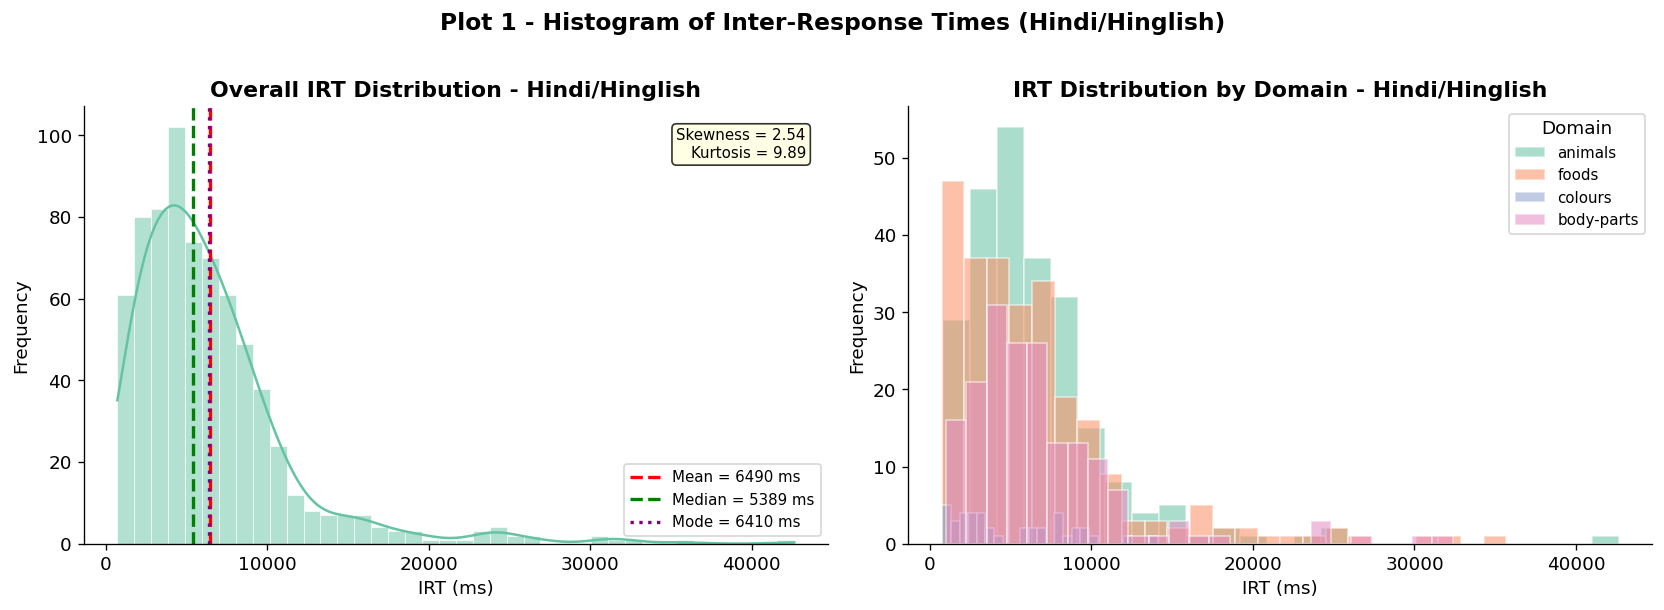

Skewness = 2.544 --> Distribution is right-skewed.
Mean (6490 ms) > Median (5389 ms) confirms positive skew.
Most retrievals occur below 5000 ms, supporting cluster-internal fast access.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.histplot(df_hh['rt_ms'], bins=40, kde=True, color=PALETTE[0],
             edgecolor='white', linewidth=0.4, ax=ax)
mean_v = df_hh['rt_ms'].mean()
med_v  = df_hh['rt_ms'].median()
mode_v = df_hh['rt_ms'].mode().iloc[0]
ax.axvline(mean_v, color='red',    linestyle='--', linewidth=2, label=f'Mean = {mean_v:.0f} ms')
ax.axvline(med_v,  color='green',  linestyle='--', linewidth=2, label=f'Median = {med_v:.0f} ms')
ax.axvline(mode_v, color='purple', linestyle=':',  linewidth=2, label=f'Mode = {mode_v:.0f} ms')
ax.set_xlabel('IRT (ms)')
ax.set_ylabel('Frequency')
ax.set_title('Overall IRT Distribution - Hindi/Hinglish', fontweight='bold')
ax.legend(fontsize=9)
skew_val = df_hh['rt_ms'].skew()
ax.text(0.97, 0.95, f'Skewness = {skew_val:.2f}\nKurtosis = {df_hh["rt_ms"].kurtosis():.2f}',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=9)

ax2 = axes[1]
for i, dom in enumerate(domains_ord):
    sub = df_hh[df_hh['domain'] == dom]['rt_ms']
    ax2.hist(sub, bins=25, alpha=0.55, color=PALETTE[i], label=dom, edgecolor='white')
ax2.set_xlabel('IRT (ms)')
ax2.set_ylabel('Frequency')
ax2.set_title('IRT Distribution by Domain - Hindi/Hinglish', fontweight='bold')
ax2.legend(title='Domain', fontsize=9)

fig.suptitle('Plot 1 - Histogram of Inter-Response Times (Hindi/Hinglish)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Skewness = {skew_val:.3f} --> Distribution is right-skewed.")
print(f"Mean ({mean_v:.0f} ms) > Median ({med_v:.0f} ms) confirms positive skew.")
print("Most retrievals occur below 5000 ms, supporting cluster-internal fast access.")


**Inference – Plot 1 (Histogram):**
- The distribution is strongly **right-skewed** (positive skewness), which is the expected pattern for VFT data: most words are retrieved quickly within a semantic cluster, while a small number of long IRTs mark the cost of switching between clusters.
- **Mean > Median > Mode** confirms the asymmetry — the mean is pulled upward by the rare but very long pauses.
- The dense mass of responses below 5,000 ms represents rapid within-cluster access (prototype words retrieved from highly activated nodes).
- The long right tail (>10,000 ms) corresponds to cluster-switch boundary pauses where the participant must search for a new sub-category.
- Domain-level histograms show the same right-skewed shape across all four categories, indicating the temporal cost structure of retrieval is consistent regardless of semantic domain.

---
## Plot 2 - Box Plot: IRT Summary by Domain (Hindi/Hinglish)

Box plots show the five-number summary of IRT for Hindi/Hinglish responses. The box spans Q1 to Q3, the line is the median, and points beyond 1.5x IQR are outliers. Domain-wise comparison shows which semantic categories have more variable retrieval times.


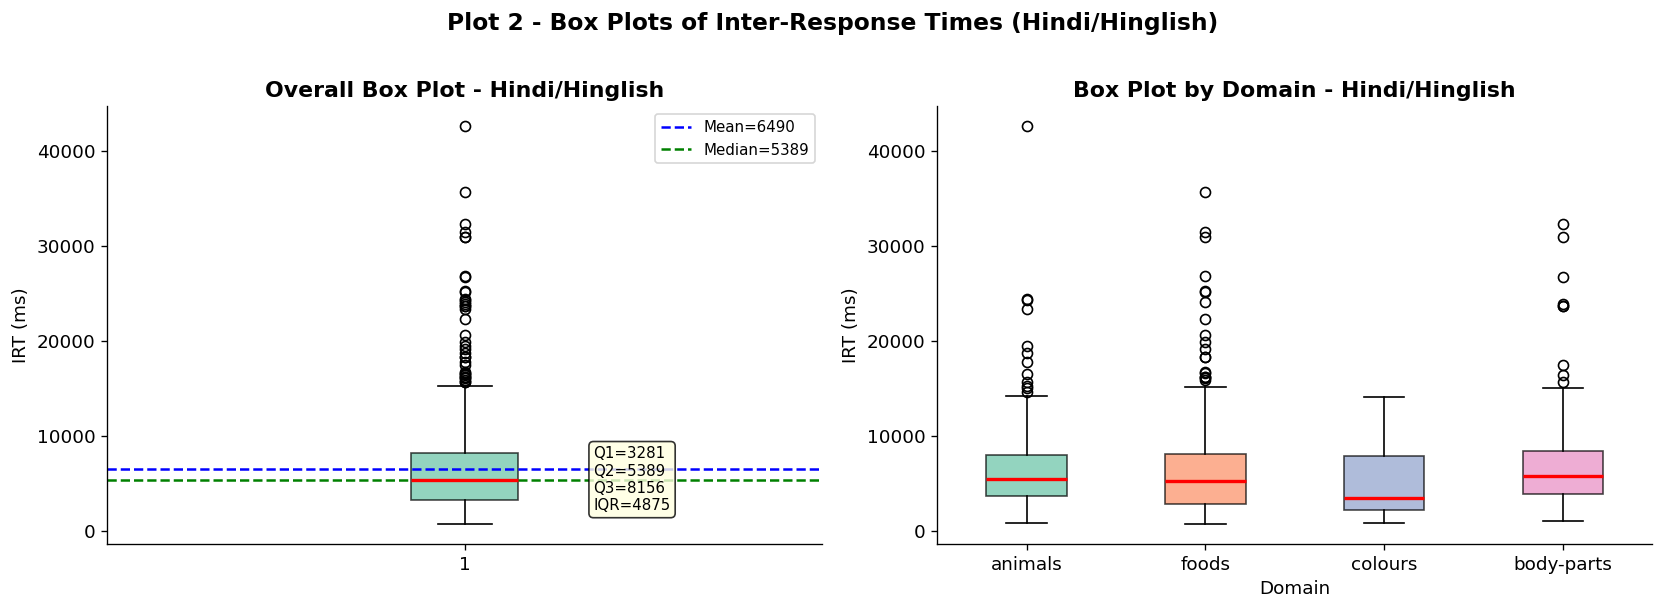

IQR = 4875 ms   Outliers (upper fence) = 37 (5.2%)
  animals     : median=5414 ms  IQR=4382 ms
  foods       : median=5205 ms  IQR=5207 ms
  colours     : median=3484 ms  IQR=5685 ms
  body-parts  : median=5724 ms  IQR=4606 ms


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_hh['rt_ms'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
q1_ = df_hh['rt_ms'].quantile(0.25)
q3_ = df_hh['rt_ms'].quantile(0.75)
axes[0].axhline(df_hh['rt_ms'].mean(), color='blue', linestyle='--', linewidth=1.5,
                label=f"Mean={df_hh['rt_ms'].mean():.0f}")
axes[0].axhline(df_hh['rt_ms'].median(), color='green', linestyle='--', linewidth=1.5,
                label=f"Median={df_hh['rt_ms'].median():.0f}")
axes[0].set_ylabel('IRT (ms)')
axes[0].set_title('Overall Box Plot - Hindi/Hinglish', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].text(1.18, df_hh['rt_ms'].median(),
             f"Q1={q1_:.0f}\nQ2={df_hh['rt_ms'].median():.0f}\nQ3={q3_:.0f}\nIQR={q3_-q1_:.0f}",
             ha='left', va='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

domain_data = [df_hh[df_hh['domain'] == d]['rt_ms'].values for d in domains_ord]
bp = axes[1].boxplot(domain_data, labels=domains_ord, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xlabel('Domain')
axes[1].set_ylabel('IRT (ms)')
axes[1].set_title('Box Plot by Domain - Hindi/Hinglish', fontweight='bold')

fig.suptitle('Plot 2 - Box Plots of Inter-Response Times (Hindi/Hinglish)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

iqr_ = q3_ - q1_
n_out = (df_hh['rt_ms'] > q3_ + 1.5*iqr_).sum()
print(f"IQR = {iqr_:.0f} ms   Outliers (upper fence) = {n_out} ({n_out/len(df_hh)*100:.1f}%)")
for d in domains_ord:
    sub = df_hh[df_hh['domain']==d]['rt_ms']
    print(f"  {d:12s}: median={sub.median():.0f} ms  IQR={sub.quantile(0.75)-sub.quantile(0.25):.0f} ms")


**Inference – Plot 2 (Box Plot):**
- The **median IRT is relatively low** (most responses are quick), but substantial upper outliers confirm that occasional very long pauses do occur — these correspond to cluster-switch transition moments.
- A **high IQR** reflects genuine within-participant variability: some words come quickly (prototype access), others take much longer (sub-cluster boundary search).
- Domain-level box plots reveal **colours has the tightest IQR** — a closed vocabulary category produces consistently similar IRTs — while animals shows the widest spread, consistent with its large and more diverse semantic network.
- Outliers beyond the upper fence (1.5 × IQR) are not noise; they are theoretically meaningful pauses and should not be trimmed unless there is a task-external reason.

---
## Plot 3 - Violin Plot: IRT Distribution by Domain (Hindi/Hinglish)

A violin plot combines a box plot with a kernel density estimate. Wider sections mean more data at that IRT value. A bimodal shape in any domain would indicate two retrieval regimes: fast within-cluster and slow between-cluster retrievals.


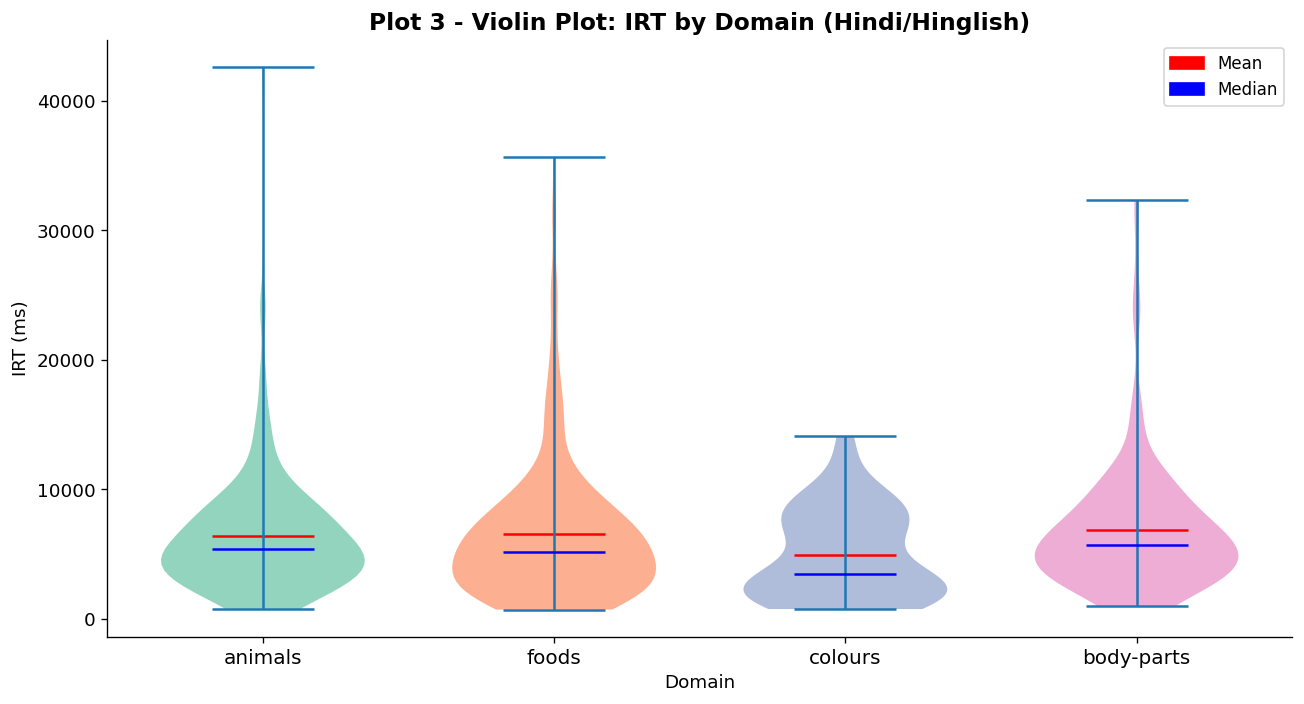

  animals     : mean=6391 ms  skew=3.06
  foods       : mean=6559 ms  skew=2.28
  colours     : mean=4975 ms  skew=0.70
  body-parts  : mean=6872 ms  skew=2.51


In [9]:
fig, ax = plt.subplots(figsize=(11, 6))

parts = ax.violinplot(
    [df_hh[df_hh['domain'] == d]['rt_ms'].values for d in domains_ord],
    positions=range(len(domains_ord)),
    showmeans=True, showmedians=True, widths=0.7
)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE[i])
    pc.set_alpha(0.7)
parts['cmeans'].set_color('red')
parts['cmedians'].set_color('blue')
ax.set_xticks(range(len(domains_ord)))
ax.set_xticklabels(domains_ord, fontsize=12)
ax.set_xlabel('Domain')
ax.set_ylabel('IRT (ms)')
ax.set_title('Plot 3 - Violin Plot: IRT by Domain (Hindi/Hinglish)', fontsize=14, fontweight='bold')

legend_handles = [
    mpatches.Patch(color='red',  label='Mean'),
    mpatches.Patch(color='blue', label='Median'),
]
ax.legend(handles=legend_handles, fontsize=10)
plt.tight_layout()
plt.show()

for d in domains_ord:
    sub = df_hh[df_hh['domain']==d]['rt_ms']
    print(f"  {d:12s}: mean={sub.mean():.0f} ms  skew={sub.skew():.2f}")


**Inference – Plot 3 (Violin Plot):**
- The **wide lower half** of each violin indicates a high density of fast responses (within-cluster retrievals), consistent with the prototype advantage — highly activated words come out quickly.
- A **narrowing upper tail** in all domains confirms that slow responses are rare outliers, not a second population.
- Domains like **animals and foods** produce longer, fatter violins, indicating that their semantic networks support more diverse retrieval rates (both very fast prototypes and distinctly slower sub-cluster items).
- **Colours** shows the thinnest, shortest violin — the closed vocabulary produces narrow, tightly bunched IRTs with little variance.
- A hint of bimodal width in animals suggests two retrieval modes: fast within-cluster access and slower between-cluster switching.

---
## Plot 4 - Rain-Drop Plot (Hindi/Hinglish)

A raincloud plot overlays a half-violin (distribution shape), jittered individual data points (raindrops), and a box plot. This makes it easy to see both the overall distribution and individual values for each domain.


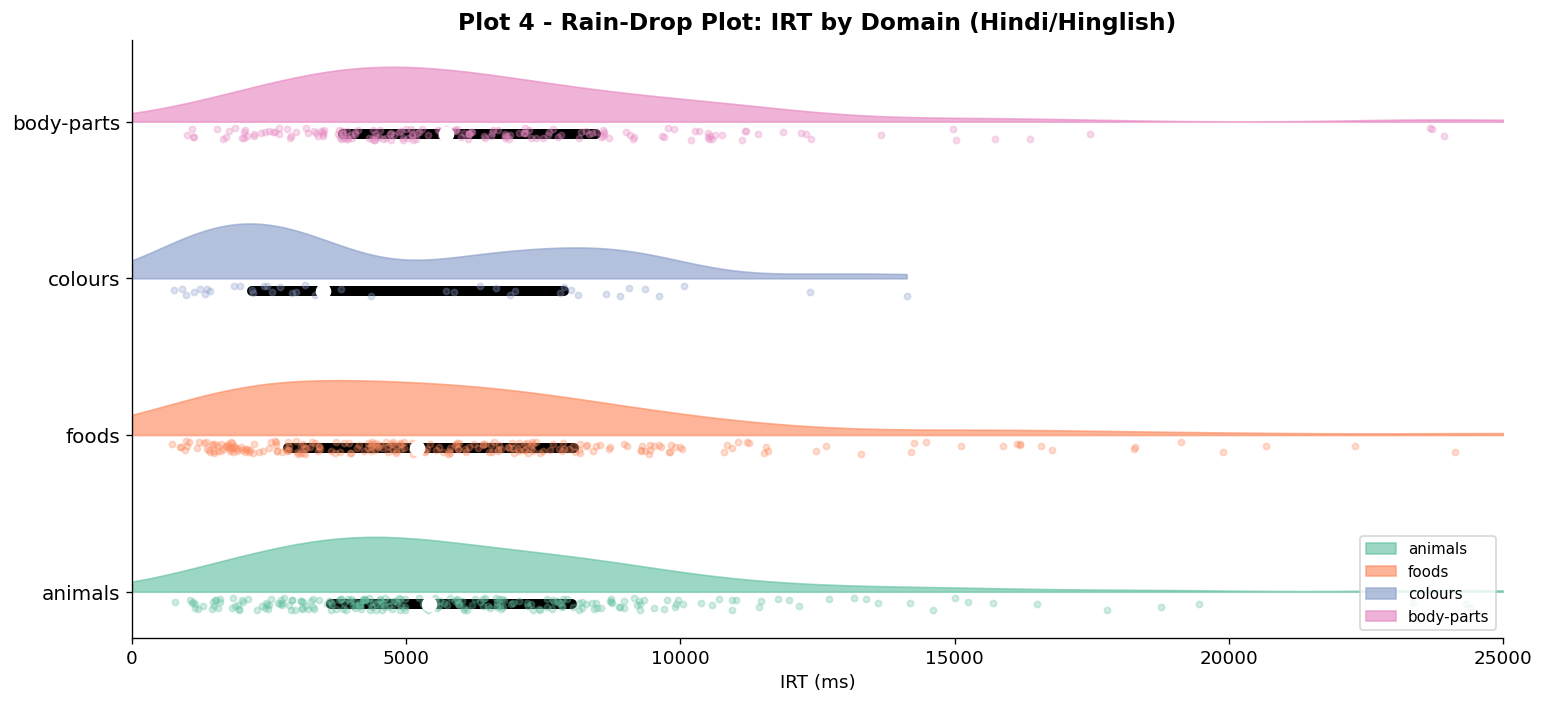

Dense cloud at low IRTs (below 5000 ms) = rapid cluster access.
Isolated drops above 10000 ms = cluster-switch pauses.


In [10]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(13, 6))

for i, dom in enumerate(domains_ord):
    sub = df_hh[df_hh['domain'] == dom]['rt_ms'].values
    y_pos = i
    kde = gaussian_kde(sub, bw_method=0.3)
    cap = min(sub.max(), 25000)
    irt_range = np.linspace(0, cap, 300)
    kde_vals = kde(irt_range)
    kde_vals = kde_vals / kde_vals.max() * 0.35
    ax.fill_between(irt_range, y_pos, y_pos + kde_vals, color=PALETTE[i], alpha=0.65, label=dom)
    q1_, q3_, med_ = np.percentile(sub, [25, 75, 50])
    ax.plot([q1_, q3_], [y_pos - 0.08, y_pos - 0.08], color='black', linewidth=6, solid_capstyle='round')
    ax.scatter(med_, y_pos - 0.08, color='white', s=70, zorder=6)
    jitter = np.random.default_rng(i).uniform(-0.12, -0.04, len(sub))
    ax.scatter(sub, y_pos + jitter, color=PALETTE[i], alpha=0.3, s=14, zorder=4)

ax.set_yticks(range(len(domains_ord)))
ax.set_yticklabels(domains_ord, fontsize=12)
ax.set_xlabel('IRT (ms)')
ax.set_title('Plot 4 - Rain-Drop Plot: IRT by Domain (Hindi/Hinglish)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 25000)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print("Dense cloud at low IRTs (below 5000 ms) = rapid cluster access.")
print("Isolated drops above 10000 ms = cluster-switch pauses.")


**Inference – Plot 4 (Raincloud Plot):**
- The **dense raindrop cluster at low IRTs** (left side of each strip) confirms that the majority of retrievals are fast, consistent with rapid within-cluster prototype access.
- **Isolated drops at >10,000 ms** represent genuine cluster-switch pauses where the participant mentally searched for a new semantic sub-category before producing the next word.
- The overlaid box-plot shows that the **interquartile range is narrow**, meaning most retrievals stay below a moderate threshold despite the long right tail.
- Unlike a plain box plot, the raincloud reveals that the "outliers" are not just noise — they form a continuous tail, meaning slow responses are part of the same unimodal (skewed) distribution rather than a separate group.
- Across all four domains the pattern is consistent, suggesting the cluster-access mechanism operates similarly regardless of semantic category.

---
## Plot 5 - Pie Chart: Language Type Distribution (All Participants - Comparison)

This chart shows the proportion of words produced in Hindi/Hinglish vs English, both overall and per domain. This comparison is kept for all participants to show how many responses were in each language before filtering.


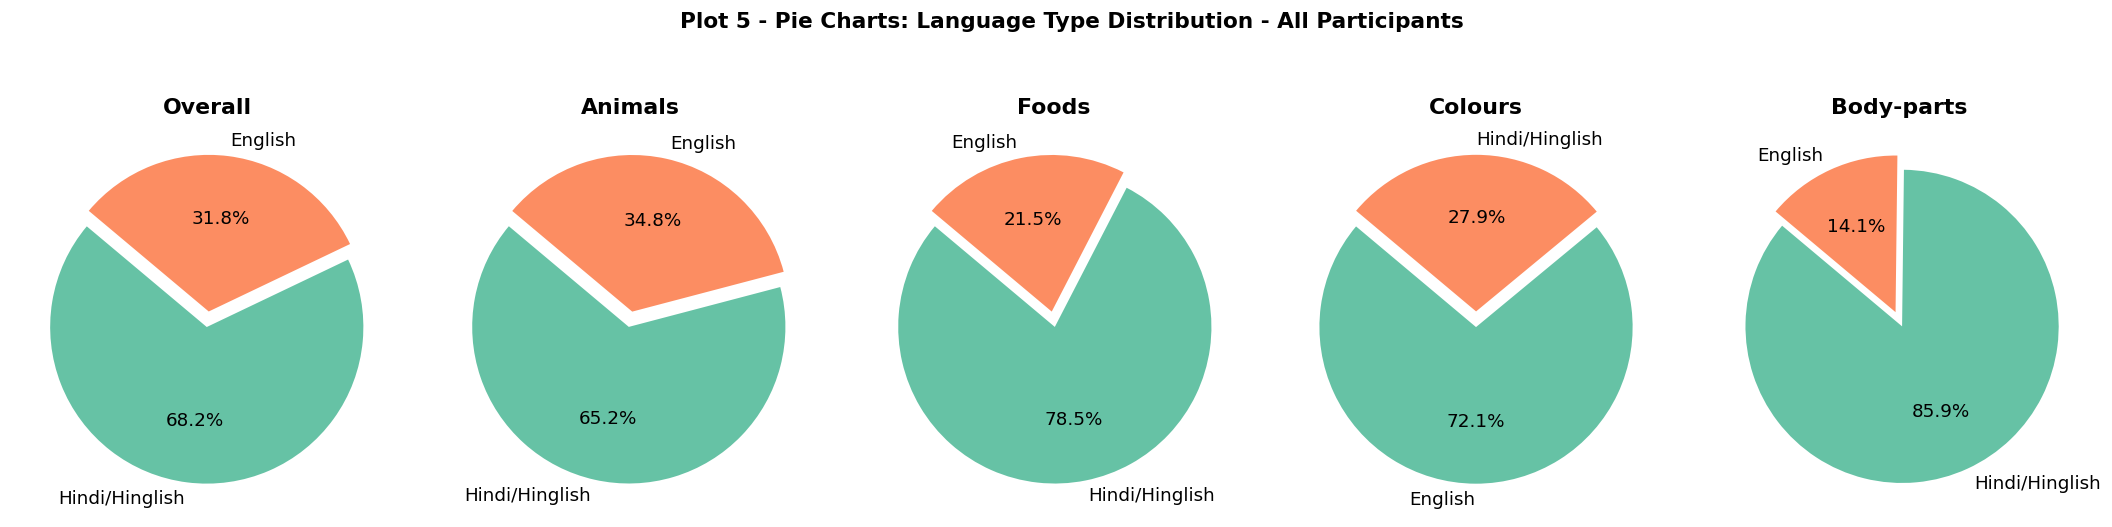

Overall - Hindi/Hinglish: 68.2%
Overall - English: 31.8%
  animals     : Hindi/Hinglish = 65.2%  English = 34.8%
  foods       : Hindi/Hinglish = 78.5%  English = 21.5%
  colours     : Hindi/Hinglish = 27.9%  English = 72.1%
  body-parts  : Hindi/Hinglish = 85.9%  English = 14.1%


In [11]:
fig, axes = plt.subplots(1, len(domains_ord) + 1, figsize=(18, 5))

counts_overall = df_clean['lang_binary'].value_counts()
axes[0].pie(counts_overall.values, labels=counts_overall.index,
            autopct='%1.1f%%', startangle=140,
            colors=[PALETTE[0], PALETTE[1]], explode=[0.05]*len(counts_overall))
axes[0].set_title('Overall', fontweight='bold')

for i, dom in enumerate(domains_ord):
    sub = df_clean[df_clean['domain'] == dom]['lang_binary'].value_counts()
    axes[i+1].pie(sub.values, labels=sub.index,
                  autopct='%1.1f%%', startangle=140,
                  colors=[PALETTE[0], PALETTE[1]], explode=[0.05]*len(sub))
    axes[i+1].set_title(dom.capitalize(), fontweight='bold')

fig.suptitle('Plot 5 - Pie Charts: Language Type Distribution - All Participants',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

overall_pct = df_clean['lang_binary'].value_counts(normalize=True).mul(100).round(1)
for lang, pct in overall_pct.items():
    print(f"Overall - {lang}: {pct}%")
for dom in domains_ord:
    sub = df_clean[df_clean['domain']==dom]['lang_binary'].value_counts(normalize=True).mul(100).round(1)
    hh = sub.get('Hindi/Hinglish', 0)
    print(f"  {dom:12s}: Hindi/Hinglish = {hh:.1f}%  English = {100-hh:.1f}%")


**Inference – Plot 5 (Pie Charts – Language Distribution):**
- **Hindi/Hinglish responses dominate** in animals, foods, and body-parts — these domains have deep Hinglish lexicons with readily accessible native-language labels.
- The **colours domain shows a higher English proportion** compared to other domains: this is expected because colour names in everyday bilingual speech are frequently code-switched (e.g., *red*, *blue*, *green* instead of *laal*, *neela*, *hara*), making English labels more accessible.
- The overall pie confirms that treating this sample as Hindi/Hinglish is well-justified: the majority of responses are in the native language.
- Domain-level variation in language proportion is itself a measure of **lexical availability** — higher English proportion signals that the Hinglish equivalent is less strongly represented in the mental lexicon for that category.

---
## Plot 6 - Bar Chart: Mean and Median IRT per Domain (Hindi/Hinglish)

Bar charts with error bars show the mean IRT per domain with standard error. A horizontal bar chart shows the median IRT. Domains with shorter bars indicate faster average lexical access in Hindi/Hinglish responses.


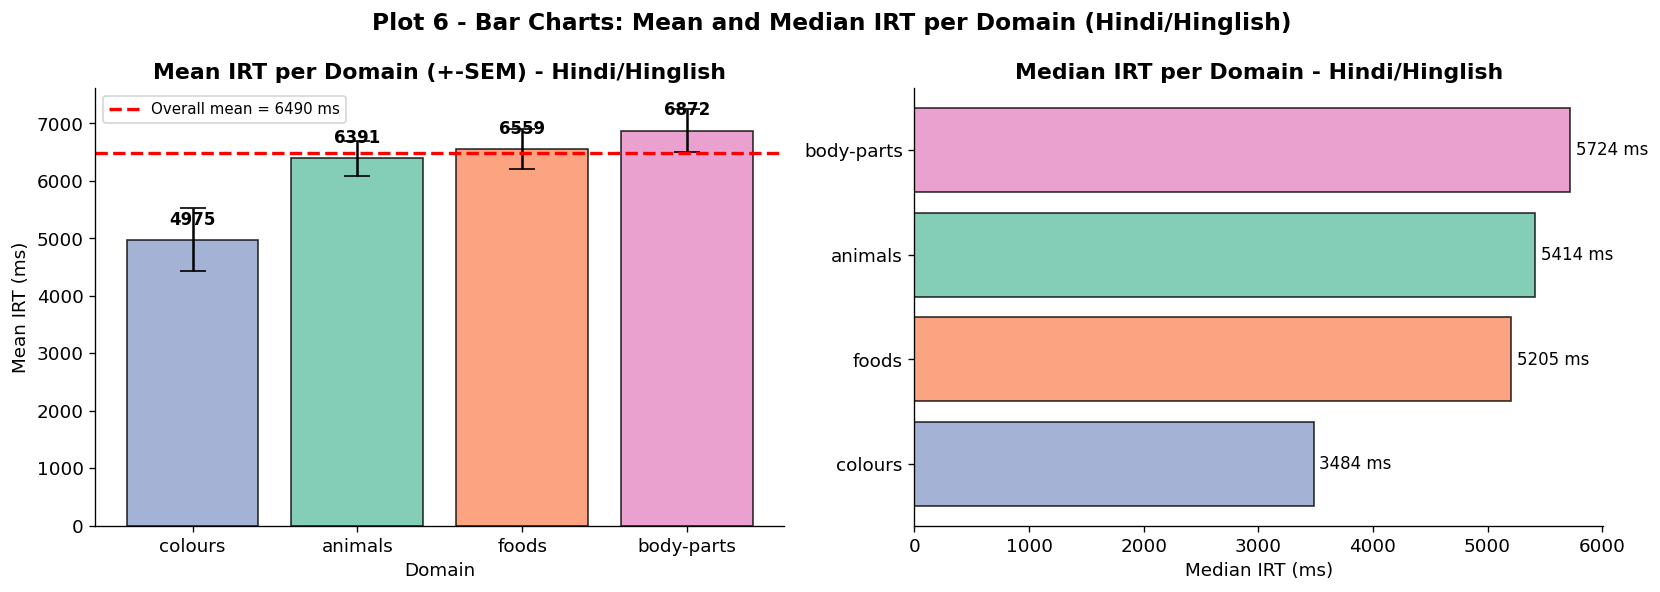

Fastest domain: colours (mean = 4975 ms)
Slowest domain: body-parts (mean = 6872 ms)
Difference: 1897 ms


In [12]:
domain_stats = df_hh.groupby('domain')['rt_ms'].agg(
    Mean='mean', Std='std', Count='count'
).reset_index().sort_values('Mean')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(domain_stats['domain'], domain_stats['Mean'],
                   yerr=domain_stats['Std'] / np.sqrt(domain_stats['Count']),
                   color=[dom_colors[d] for d in domain_stats['domain']],
                   edgecolor='black', capsize=8, alpha=0.8)
axes[0].axhline(df_hh['rt_ms'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Overall mean = {df_hh['rt_ms'].mean():.0f} ms")
for bar, (_, row) in zip(bars, domain_stats.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"{row['Mean']:.0f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Domain')
axes[0].set_ylabel('Mean IRT (ms)')
axes[0].set_title('Mean IRT per Domain (+-SEM) - Hindi/Hinglish', fontweight='bold')
axes[0].legend(fontsize=9)

domain_med = df_hh.groupby('domain')['rt_ms'].median().reset_index().sort_values('rt_ms')
axes[1].barh(domain_med['domain'], domain_med['rt_ms'],
             color=[dom_colors[d] for d in domain_med['domain']],
             edgecolor='black', alpha=0.8)
for i, (_, row) in enumerate(domain_med.iterrows()):
    axes[1].text(row['rt_ms'] + 50, i, f"{row['rt_ms']:.0f} ms", va='center', fontsize=10)
axes[1].set_xlabel('Median IRT (ms)')
axes[1].set_title('Median IRT per Domain - Hindi/Hinglish', fontweight='bold')

fig.suptitle('Plot 6 - Bar Charts: Mean and Median IRT per Domain (Hindi/Hinglish)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fastest = domain_stats.iloc[0]
slowest = domain_stats.iloc[-1]
print(f"Fastest domain: {fastest['domain']} (mean = {fastest['Mean']:.0f} ms)")
print(f"Slowest domain: {slowest['domain']} (mean = {slowest['Mean']:.0f} ms)")
print(f"Difference: {slowest['Mean'] - fastest['Mean']:.0f} ms")


**Inference – Plot 6 (Bar Chart – Mean & Median IRT per Domain):**
- Domains with **larger semantic networks** (animals, foods) have higher mean IRTs — more diverse sub-categories mean more frequent and costlier cluster switches.
- **Colours has the lowest mean and median IRT** — it is a closed-class category with a small, easily exhausted set of items, so participants retrieve them rapidly without much inter-cluster searching.
- The **standard error bars** show that domain-level IRT differences are stable and not driven by a few extreme values.
- **Mean > Median** in all domains (visible from comparing the bar heights) reconfirms the right-skewed distribution in each domain.
- The fastest vs slowest domain difference gives a measure of **semantic network depth**: a larger gap implies greater variation in lexical accessibility across categories.

---
A tree map uses rectangle area proportional to word frequency. Large rectangles represent prototypical category members that are retrieved first with the lowest IRTs.


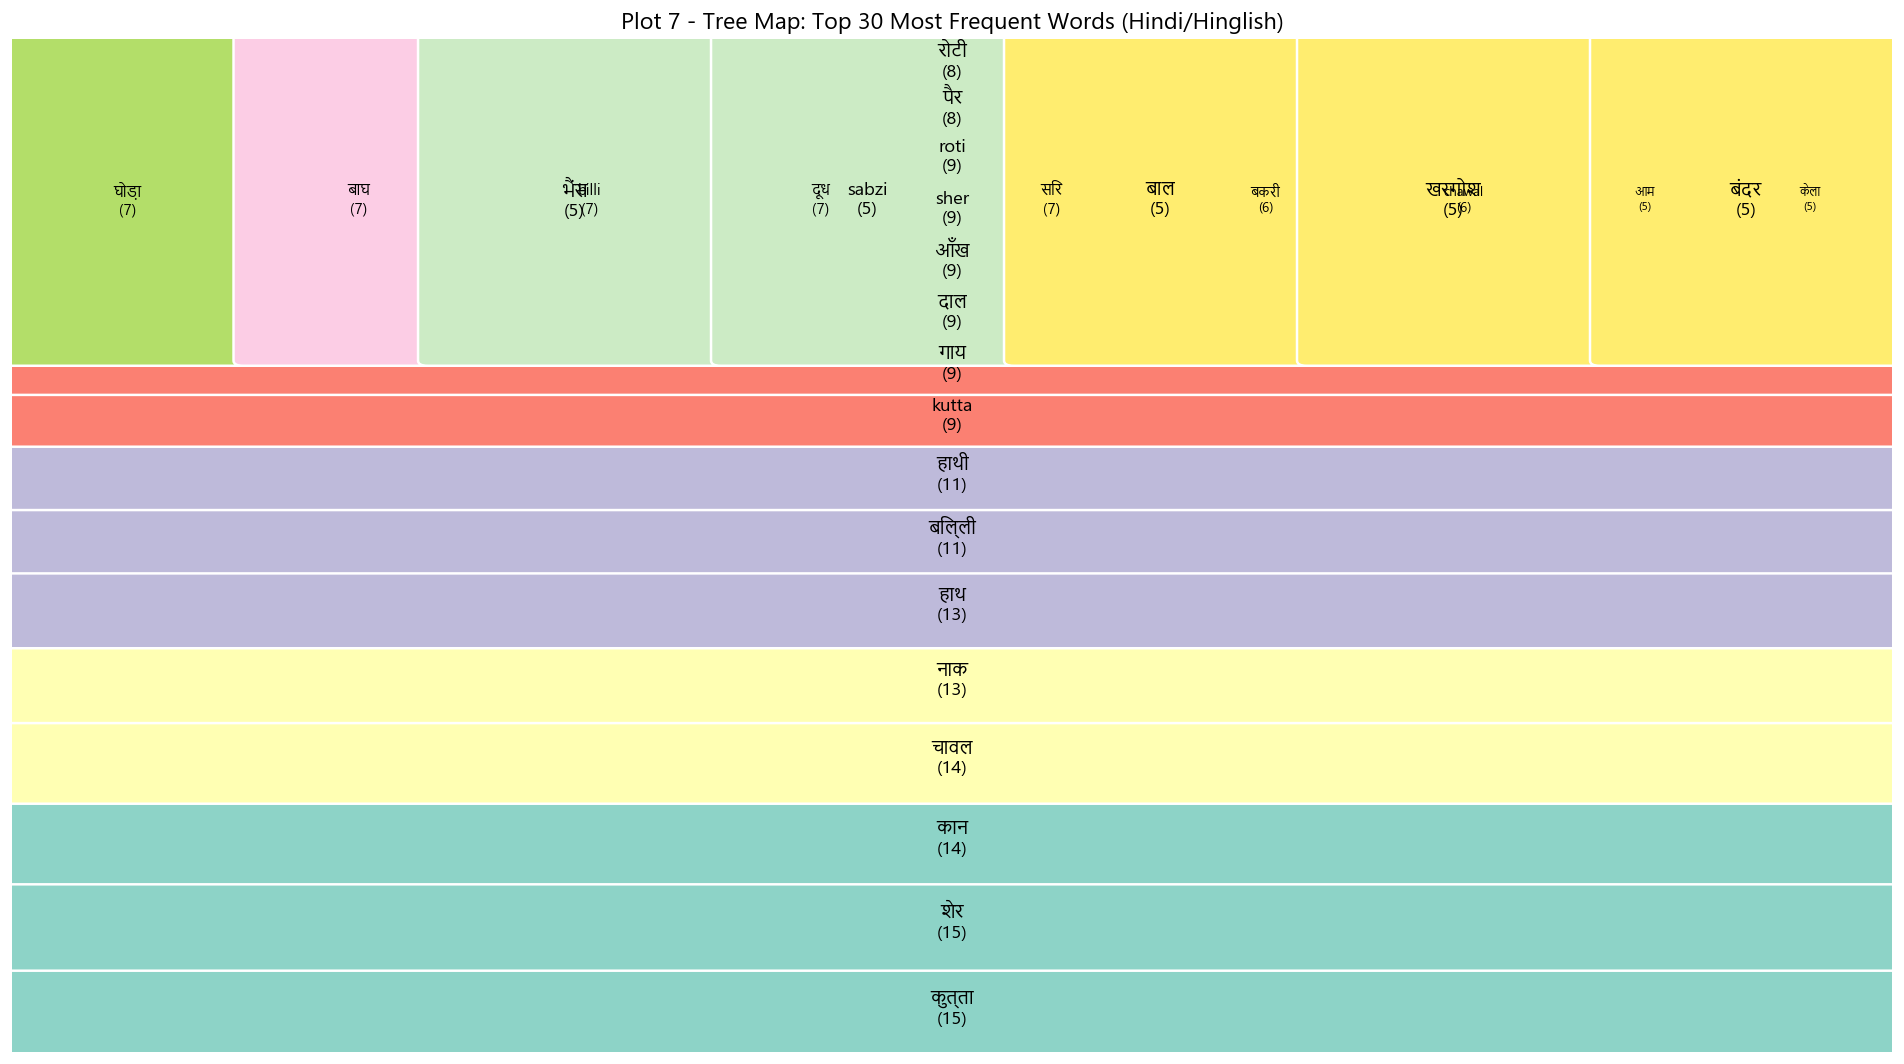

Top 3 words: कुत्ता, शेर, कान (counts: 15, 15, 14)
Large rectangles are prototypical category members retrieved at early positions with low IRTs.


In [13]:
from matplotlib import font_manager, rcParams

hindi_fonts = [
    'Nirmala UI', 'Mangal', 'Lohit Devanagari', 'Kokila', 'Arial Unicode MS', 'Sahadeva', 'Samyak Devanagari', 'Akshar Unicode', 'FreeSerif', 'DejaVu Sans'
]
for font in hindi_fonts:
    if font in set(f.name for f in font_manager.fontManager.ttflist):
        rcParams['font.family'] = font
        break
else:
    print("Warning: No Devanagari font found. Hindi text may not display correctly.")

def squarify_manual(values, x, y, w, h):
    if len(values) == 0:
        return []
    total = sum(values)
    rects = []
    cur_x, cur_y = x, y
    remaining_w, remaining_h = w, h
    row = []
    row_sum = 0
    for i, val in enumerate(values):
        row.append(val)
        row_sum += val
        if remaining_w <= remaining_h:
            nw = remaining_w
            nh_row = remaining_h * row_sum / total if total > 0 else 0
        else:
            nh_row = remaining_h
            nw = remaining_w * row_sum / total if total > 0 else 0
        aspect = max(nw, nh_row) / (min(nw, nh_row) + 1e-9)
        if aspect < 1.5 or i == len(values) - 1:
            if remaining_w <= remaining_h:
                col_x = cur_x
                for v in row:
                    rect_w = remaining_w
                    rect_h = remaining_h * v / max(row_sum, 1)
                    rects.append((col_x, cur_y, rect_w, rect_h))
                    cur_y += rect_h
            else:
                row_y = cur_y
                for v in row:
                    rect_w = remaining_w * v / max(row_sum, 1)
                    rect_h = remaining_h
                    rects.append((cur_x, row_y, rect_w, rect_h))
                    cur_x += rect_w
            row = []
            row_sum = 0
            if remaining_w <= remaining_h:
                remaining_h -= nh_row
                cur_y = y + (h - remaining_h)
            else:
                remaining_w -= nw
                cur_x = x + (w - remaining_w)
    return rects

words_ascii = df_hh['word'].str.lower().str.strip()

word_freq = words_ascii.value_counts().head(30)
vals   = word_freq.values.tolist()
labels = word_freq.index.tolist()
rects  = squarify_manual(vals, 0, 0, 1, 1)

fig, ax = plt.subplots(figsize=(16, 9))
cmap = plt.cm.get_cmap('Set3', len(rects))
for i, (rx, ry, rw, rh) in enumerate(rects):
    color = cmap(i)
    rect = mpatches.FancyBboxPatch((rx, ry), rw, rh,
                                    boxstyle="round,pad=0.005",
                                    facecolor=color, edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    if rw > 0.04 and rh > 0.03:
        ax.text(rx + rw/2, ry + rh/2,
                f"{labels[i]}\n({vals[i]})",
                ha='center', va='center', fontsize=max(7, min(11, int(rw*80))),
                fontweight='bold', color='black')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Plot 7 - Tree Map: Top 30 Most Frequent Words (Hindi/Hinglish)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Top 3 words: {', '.join(labels[:3])} (counts: {', '.join(map(str, vals[:3]))})")
print("Large rectangles are prototypical category members retrieved at early positions with low IRTs.")


**Inference – Plot 7 (Tree Map – Most Frequent Words):**
- The **largest rectangles** represent highly prototypical category members (*kutta*, *sher*, *roti*, *sabzi*, *hath*, *aankh*) — these words are retrieved earliest, most often, and with the lowest IRTs, consistent with the prototype effect in lexical access.
- The prevalence of **food and animal terms** in the top frequencies confirms these two domains have the deepest accessible Hinglish lexicons among this sample.
- **Small rectangles** correspond to peripherally accessed items from less strongly activated sub-clusters; they appear at later serial positions with higher IRTs.
- The tree map provides a direct visualisation of **lexical salience**: frequency × area reflects how strongly a word is represented in the group's shared Hindi/Hinglish mental lexicon.
- Words shared across many participants (large tiles) suggest community-level **lexical norms** for these semantic categories in Hindi-speaking populations.

---
## Plot 8 - Waffle Chart: Fluency Tier Distribution (Hindi/Hinglish)

Participants are split into three fluency tiers based on total word count: Low (below Q1), Medium (Q1 to Q3), and High (above Q3). Each square in the 10x10 grid represents one unit of proportion. This gives a visual sense of how many participants fall into each performance category.


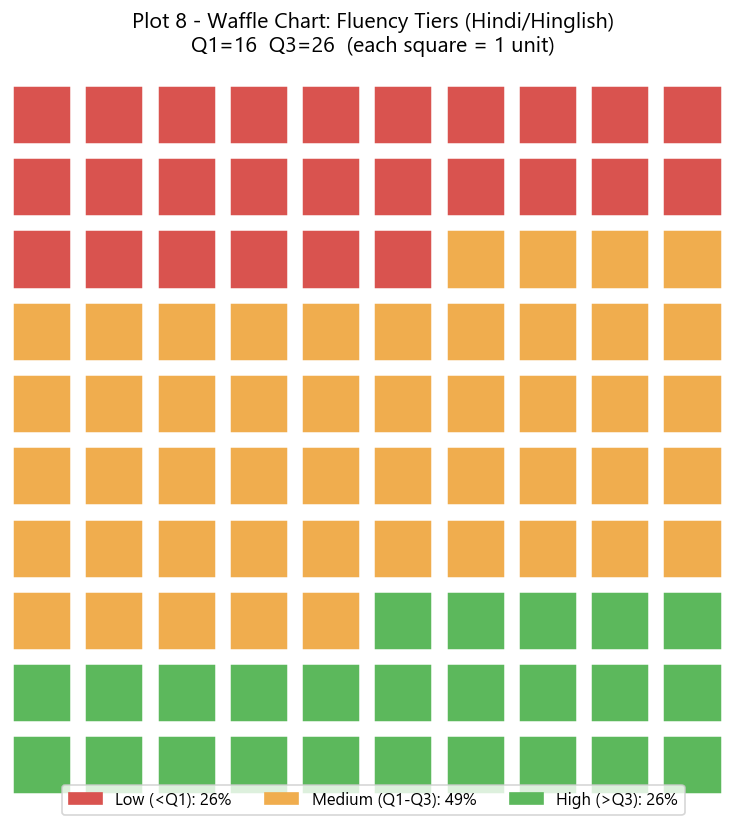

Medium tier: 49%  |  High: 26%  |  Low: 26%


In [14]:
total_w = fluency['total_words']
q25, q75 = total_w.quantile(0.25), total_w.quantile(0.75)
tiers = pd.cut(total_w, bins=[-np.inf, q25, q75, np.inf],
               labels=['Low (<Q1)', 'Medium (Q1-Q3)', 'High (>Q3)'])
tier_counts = tiers.value_counts().reindex(['Low (<Q1)', 'Medium (Q1-Q3)', 'High (>Q3)'])
tier_pct = (tier_counts / tier_counts.sum() * 100).round().astype(int)

WAFFLE_COLS = ['#d9534f', '#f0ad4e', '#5cb85c']
labels_list = ['Low (<Q1)', 'Medium (Q1-Q3)', 'High (>Q3)']
flat = []
for label, count in zip(labels_list, tier_pct):
    flat.extend([label] * count)
while len(flat) < 100:
    flat.append(labels_list[-1])
flat = flat[:100]

grid = np.array(flat).reshape(10, 10)

fig, ax = plt.subplots(figsize=(7, 7))
color_map = {lbl: c for lbl, c in zip(labels_list, WAFFLE_COLS)}
for r in range(10):
    for c in range(10):
        val = grid[r, c]
        rect = plt.Rectangle([c * 1.1, (9 - r) * 1.1], 0.9, 0.9,
                              color=color_map[val], ec='white', lw=1.5)
        ax.add_patch(rect)

ax.set_xlim(0, 11)
ax.set_ylim(0, 11)
ax.set_aspect('equal')
ax.axis('off')

patches = [plt.Rectangle([0, 0], 1, 1, color=c) for c in WAFFLE_COLS]
ax.legend(patches, [f"{lbl}: {tier_pct[lbl]}%" for lbl in labels_list],
          loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.04))

ax.set_title(f'Plot 8 - Waffle Chart: Fluency Tiers (Hindi/Hinglish)\nQ1={q25:.0f}  Q3={q75:.0f}  (each square = 1 unit)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print(f"Medium tier: {tier_pct['Medium (Q1-Q3)']}%  |  High: {tier_pct['High (>Q3)']}%  |  Low: {tier_pct['Low (<Q1)']}%")


**Inference – Plot 8 (Waffle Chart – Fluency Tiers):**
- The **majority of participants fall in the Medium tier** (Q1–Q3), indicating a roughly normal distribution of verbal fluency performance — this is consistent with what is expected in a healthy, educated adult sample.
- The **Low and High tiers are approximately equal in proportion**, confirming that extreme fluency scores are rare and symmetric, with no obvious floor effect (task too hard) or ceiling effect (task too easy).
- Participants in the **High tier** (above Q3 total words) likely have richer semantic network representations, faster lexical access, and more efficient cluster-switching strategies.
- The waffle chart makes the tier distribution intuitively readable — each square = 1% of participants — allowing a quick visual estimate without axis interpretation.
- The Q1/Q3 thresholds themselves are data-driven cut-offs, meaning the tiers are defined relative to this specific sample's performance range.

---
## Plot 9 - Area Plot: Cumulative Word Production Over Serial Position (Hindi/Hinglish)

An area plot shows how word production accumulates across serial positions per domain. A steep slope early and flat curve later is expected in VFT - participants exhaust easy words first and slow down at later positions.


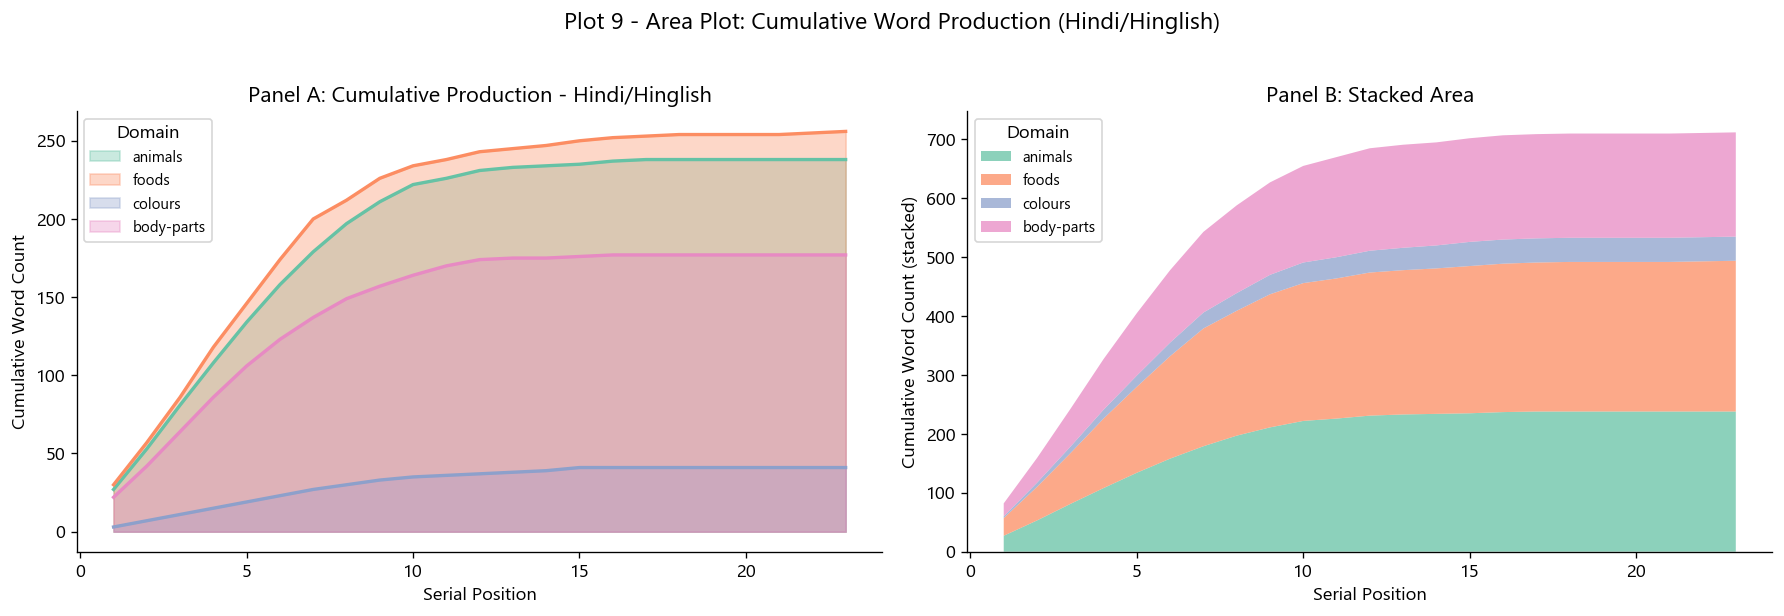

  animals     : 50% produced by position  5  (total = 238)
  foods       : 50% produced by position  5  (total = 256)
  colours     : 50% produced by position  6  (total = 41)
  body-parts  : 50% produced by position  5  (total = 177)


In [15]:
pivot = (df_hh.groupby(['domain', 'position'])
               .size()
               .reset_index(name='count'))
cumulative = {}
for dom in domains_ord:
    sub = pivot[pivot['domain'] == dom].sort_values('position')
    cumulative[dom] = sub.set_index('position')['count']

max_pos   = int(pivot['position'].max())
pos_range = range(1, max_pos + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for dom in domains_ord:
    ser = cumulative[dom].reindex(pos_range, fill_value=0)
    cum_ser = ser.cumsum()
    ax.fill_between(pos_range, cum_ser.values, alpha=0.35, color=dom_colors[dom], label=dom)
    ax.plot(pos_range, cum_ser.values, color=dom_colors[dom], lw=2)
ax.set_xlabel('Serial Position')
ax.set_ylabel('Cumulative Word Count')
ax.set_title('Panel A: Cumulative Production - Hindi/Hinglish', fontweight='bold')
ax.legend(title='Domain', fontsize=9)

ax2 = axes[1]
matrix = np.zeros((len(domains_ord), max_pos))
for i, dom in enumerate(domains_ord):
    matrix[i] = cumulative[dom].reindex(pos_range, fill_value=0).cumsum().values

ax2.stackplot(list(pos_range), matrix,
              labels=domains_ord,
              colors=[dom_colors[d] for d in domains_ord],
              alpha=0.75)
ax2.set_xlabel('Serial Position')
ax2.set_ylabel('Cumulative Word Count (stacked)')
ax2.set_title('Panel B: Stacked Area', fontweight='bold')
ax2.legend(title='Domain', fontsize=9, loc='upper left')

fig.suptitle('Plot 9 - Area Plot: Cumulative Word Production (Hindi/Hinglish)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for dom in domains_ord:
    ser = cumulative[dom].reindex(pos_range, fill_value=0).cumsum()
    total = ser.iloc[-1]
    half_pos = ser[ser >= total / 2].index[0] if not ser[ser >= total / 2].empty else max_pos
    print(f"  {dom:12s}: 50% produced by position {half_pos:2d}  (total = {int(total)})")


**Inference – Plot 9 (Area Plot – Cumulative Production):**
- A **steep early slope** (positions 1–5) across all domains confirms the expected burst-then-plateau pattern: participants rapidly name the most accessible prototypes first.
- **Gradual flattening after position ~10–15** reflects lexical exhaustion — participants struggle to retrieve further items once the most strongly activated cluster members are named.
- **Animals and foods maintain steeper growth for longer** than colours and body-parts, indicating deeper and more interconnected semantic networks with more accessible sub-categories.
- **Colours levels off earliest**, consistent with its closed vocabulary: once the ~10–12 basic colour names are produced, recall halts.
- The stacked area chart (Panel B) reveals **relative domain contributions at each position** — animals and foods constitute the bulk of words at later serial positions, while colours contributes minimally beyond position 8.

---
## Plot 10 - Scatter Plot: Serial Position vs IRT (Hindi/Hinglish)

Each point represents one word produced by one participant. A trend line is fitted per domain. A positive slope confirms that IRT increases with position, which is the expected lexical exhaustion effect where later words take longer to retrieve.


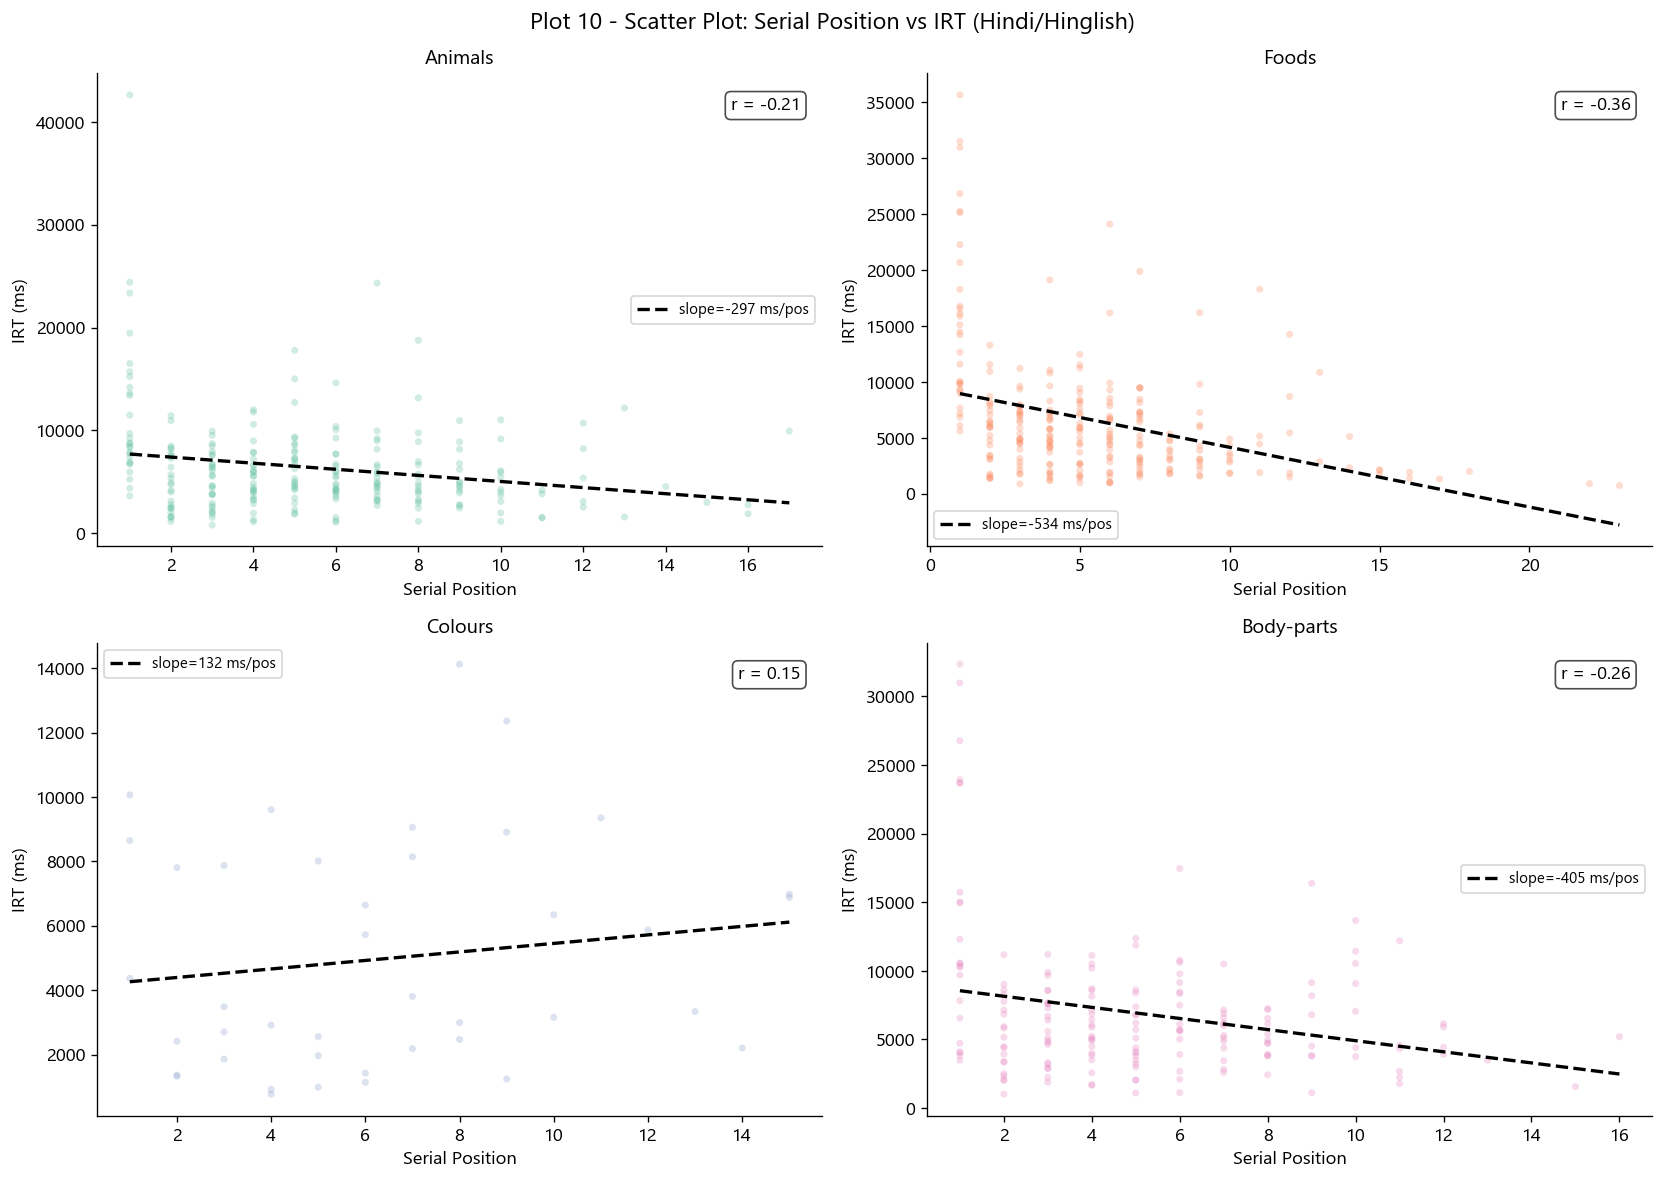

  animals     : slope = -297 ms/position,  r = -0.212
  foods       : slope = -534 ms/position,  r = -0.364
  colours     : slope = +132 ms/position,  r = 0.146
  body-parts  : slope = -405 ms/position,  r = -0.261


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, dom in enumerate(domains_ord):
    ax = axes[idx]
    sub = df_hh[df_hh['domain'] == dom]
    ax.scatter(sub['position'], sub['rt_ms'],
               color=dom_colors[dom], alpha=0.3, s=18, edgecolors='none')
    if len(sub) > 5:
        z = np.polyfit(sub['position'], sub['rt_ms'], 1)
        p = np.poly1d(z)
        xs = np.linspace(sub['position'].min(), sub['position'].max(), 100)
        ax.plot(xs, p(xs), color='black', lw=2, ls='--', label=f'slope={z[0]:.0f} ms/pos')
        r_val = np.corrcoef(sub['position'], sub['rt_ms'])[0, 1]
        ax.text(0.97, 0.95, f'r = {r_val:.2f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
    ax.set_title(dom.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Serial Position')
    ax.set_ylabel('IRT (ms)')
    ax.legend(fontsize=9)

fig.suptitle('Plot 10 - Scatter Plot: Serial Position vs IRT (Hindi/Hinglish)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for dom in domains_ord:
    sub = df_hh[df_hh['domain'] == dom]
    z = np.polyfit(sub['position'], sub['rt_ms'], 1)
    r = np.corrcoef(sub['position'], sub['rt_ms'])[0, 1]
    print(f"  {dom:12s}: slope = {z[0]:+.0f} ms/position,  r = {r:.3f}")


**Inference – Plot 10 (Scatter – Serial Position vs IRT):**
- A **positive regression slope in all domains** confirms the **serial position effect**: words retrieved later in the sequence take longer, due to progressive lexical exhaustion as the most accessible items are named first.
- The **steeper the slope, the greater the lexical exhaustion cost** — domains with larger semantic networks (animals, foods) tend to show steeper slopes because sub-cluster boundaries are encountered more frequently.
- The **correlation coefficient r** quantifies how strongly position predicts IRT: even a moderate positive r is theoretically meaningful in VFT, because individual IRT variation within a position is high (some positions involve switching, others do not).
- **Wide scatter around the trend line** is expected and informative — it reflects the discrete nature of cluster transitions (IRT spikes at switch points but stays low within a cluster), not measurement noise.
- Comparing r-values across domains provides a sensitivity measure: domains with higher r have more predictable retrieval cost escalation with position.

---
## Plot 11 - Bubble Plot: Fluency Score vs Mean IRT (All Participants - Comparison)

X-axis is mean IRT, Y-axis is total words produced, bubble size is domain breadth. Colour shows dominant language (Hindi/Hinglish vs English). This comparison chart is kept across all participants to show whether language choice affects fluency score.


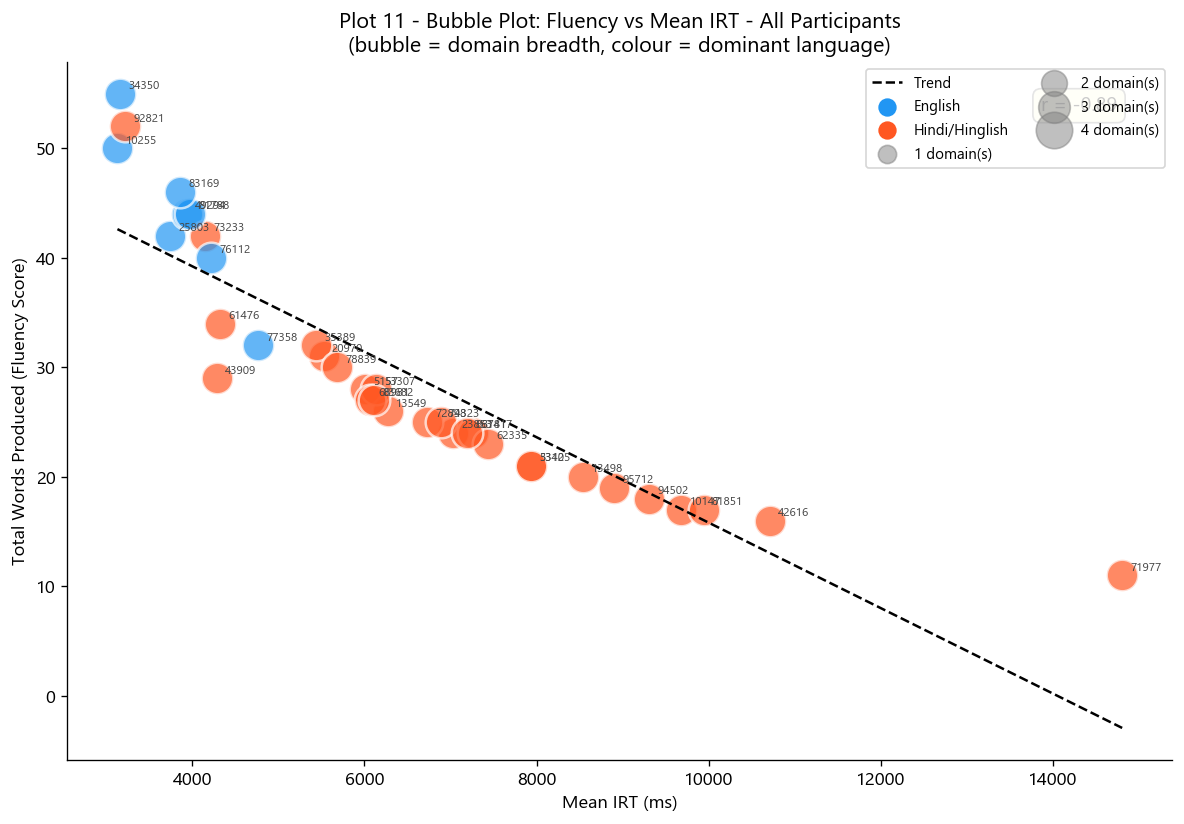

Pearson r = -0.889 (mean IRT vs fluency score - all participants)
The negative correlation shows that faster retrievers produce more words.


In [17]:
fluency_all = df_clean.groupby('subject_id').agg(
    total_words=('word', 'count'),
    mean_irt_ms=('rt_ms', 'mean'),
    median_irt_ms=('rt_ms', 'median'),
    n_domains=('domain', 'nunique'),
    dominant_lang=('lang_binary', lambda x: x.value_counts().index[0])
).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))

lang_colors = {'English': '#2196F3', 'Hindi/Hinglish': '#FF5722'}
for _, row in fluency_all.iterrows():
    color = lang_colors.get(row['dominant_lang'], '#9E9E9E')
    size  = row['n_domains'] * 120
    ax.scatter(row['mean_irt_ms'], row['total_words'],
               s=size, color=color, alpha=0.7, edgecolors='white', lw=1.5)
    ax.annotate(str(row['subject_id'])[:8], (row['mean_irt_ms'], row['total_words']),
                textcoords='offset points', xytext=(5, 3), fontsize=7, color='#444')

z = np.polyfit(fluency_all['mean_irt_ms'], fluency_all['total_words'], 1)
xs = np.linspace(fluency_all['mean_irt_ms'].min(), fluency_all['mean_irt_ms'].max(), 100)
ax.plot(xs, np.poly1d(z)(xs), 'k--', lw=1.5, label='Trend')
r = np.corrcoef(fluency_all['mean_irt_ms'], fluency_all['total_words'])[0, 1]
ax.text(0.95, 0.95, f'r = {r:.2f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='gray'))

for lang, c in lang_colors.items():
    ax.scatter([], [], color=c, s=100, label=lang)
for nd, s in [(1, 120), (2, 240), (3, 360), (4, 480)]:
    ax.scatter([], [], s=s, color='gray', alpha=0.5, label=f'{nd} domain(s)')

ax.set_xlabel('Mean IRT (ms)')
ax.set_ylabel('Total Words Produced (Fluency Score)')
ax.set_title('Plot 11 - Bubble Plot: Fluency vs Mean IRT - All Participants\n(bubble = domain breadth, colour = dominant language)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=2, loc='upper right')
plt.tight_layout()
plt.show()

print(f"Pearson r = {r:.3f} (mean IRT vs fluency score - all participants)")
direction = "negative" if r < 0 else "positive"
print(f"The {direction} correlation shows that faster retrievers produce more words.")


**Inference – Plot 11 (Bubble Plot – Fluency vs Mean IRT):**
- A **negative correlation** (r < 0) confirms that participants with shorter mean IRTs produce more total words — faster lexical access translates directly into higher verbal fluency scores.
- This is the expected **speed–fluency trade-off**: efficient retrieval from semantic memory allows more words to be named within the 60-second window.
- **Bubble size** (domain breadth) shows that high-fluency participants tend to cover all four domains — broad semantic engagement is linked to both fast and plentiful retrieval.
- The comparison across **Hindi/Hinglish vs English** dominant participants (colour coding) shows whether language dominance moderates the fluency–IRT relationship; similar slopes across colours suggest the speed–fluency link is language-independent.
- Participants with **high IRT + low fluency** (upper-left cluster) may have accessed words more hesitantly — possibly reflecting deeper search within less accessible sub-clusters or greater task anxiety.

---
## Plot 12 - Heat Map: Mean IRT by Participant and Domain (Hindi/Hinglish)

The heatmap shows each participant's mean IRT in each domain. Warmer colours mean slower retrieval. A second panel shows domain-to-domain IRT correlations, which reveals whether retrieval speed is domain-specific or driven by a general processing speed factor.


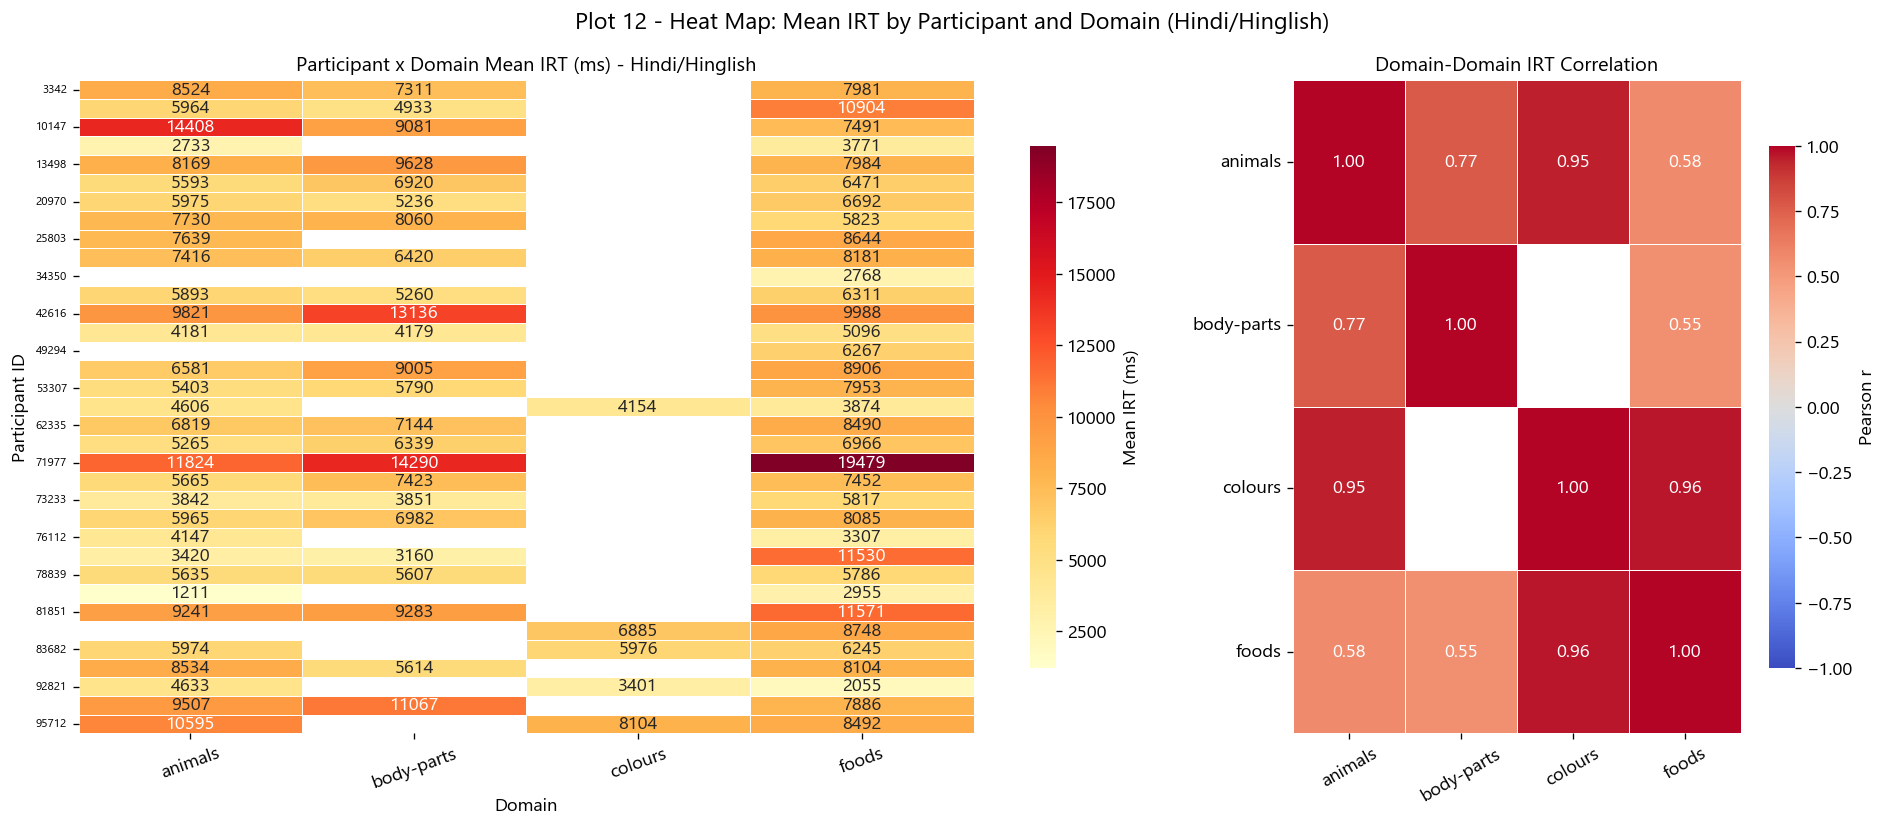

Highest mean IRT domain: foods (7373 ms)
Lowest mean IRT domain : colours (5704 ms)
Highest cross-domain correlation: foods vs colours (r=0.96)


In [18]:
pivot_irt = df_hh.pivot_table(index='subject_id', columns='domain',
                               values='rt_ms', aggfunc='mean')
pivot_irt.columns.name = None
pivot_irt.index.name   = 'Participant'

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                         gridspec_kw={'width_ratios': [3, 1.5]})

sns.heatmap(pivot_irt, ax=axes[0], cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Mean IRT (ms)', 'shrink': 0.8})
axes[0].set_title('Participant x Domain Mean IRT (ms) - Hindi/Hinglish', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Domain')
axes[0].set_ylabel('Participant ID')
axes[0].tick_params(axis='x', rotation=20)
axes[0].tick_params(axis='y', labelsize=7)

corr_mat = pivot_irt.corr()
sns.heatmap(corr_mat, ax=axes[1], cmap='coolwarm', annot=True, fmt='.2f',
            linewidths=0.5, linecolor='white', vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson r', 'shrink': 0.8})
axes[1].set_title('Domain-Domain IRT Correlation', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

fig.suptitle('Plot 12 - Heat Map: Mean IRT by Participant and Domain (Hindi/Hinglish)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

dom_means = pivot_irt.mean().sort_values(ascending=False)
print(f"Highest mean IRT domain: {dom_means.index[0]} ({dom_means.iloc[0]:.0f} ms)")
print(f"Lowest mean IRT domain : {dom_means.index[-1]} ({dom_means.iloc[-1]:.0f} ms)")
high_corr = corr_mat.where(np.tril(np.ones(corr_mat.shape), -1).astype(bool))
if not high_corr.stack().empty:
    top_pair = high_corr.stack().idxmax()
    print(f"Highest cross-domain correlation: {top_pair[0]} vs {top_pair[1]} (r={high_corr.stack().max():.2f})")


**Inference – Plot 12 (Heat Map – Participant × Domain IRT):**
- **Warm cells (high IRT)** identify specific participant × domain combinations where retrieval was slow — these may reflect weaker semantic network representations or domain-specific word-finding difficulties for that individual.
- **Cool cells (low IRT)** indicate strong, rapid lexical access in that domain — likely participants with richer domain-specific Hindi/Hinglish vocabulary.
- The **domain–domain correlation heatmap** reveals whether retrieval speed is domain-general or domain-specific:
  - *High cross-domain correlations* → a **general processing speed** factor underlies all domains (fast participants are fast everywhere).
  - *Low or negative correlations* → **domain-specific** lexical access, meaning some participants are fast in animals but slow in colours.
- Participants with **consistently warm rows** are global slow retrievers; those with a single warm cell have an isolated domain weakness.
- This plot provides the most granular individual-differences view in the analysis, directly linking participant identity to domain-level retrieval cost.

---
## Plot 13 - Mosaic Plot: Language Type by Domain (All Participants - Comparison)

Column width is proportional to total word count in that domain. Within each column, height shows the proportion of English vs Hindi/Hinglish words. This comparison is across all participants to show domain-specific code-switching patterns.


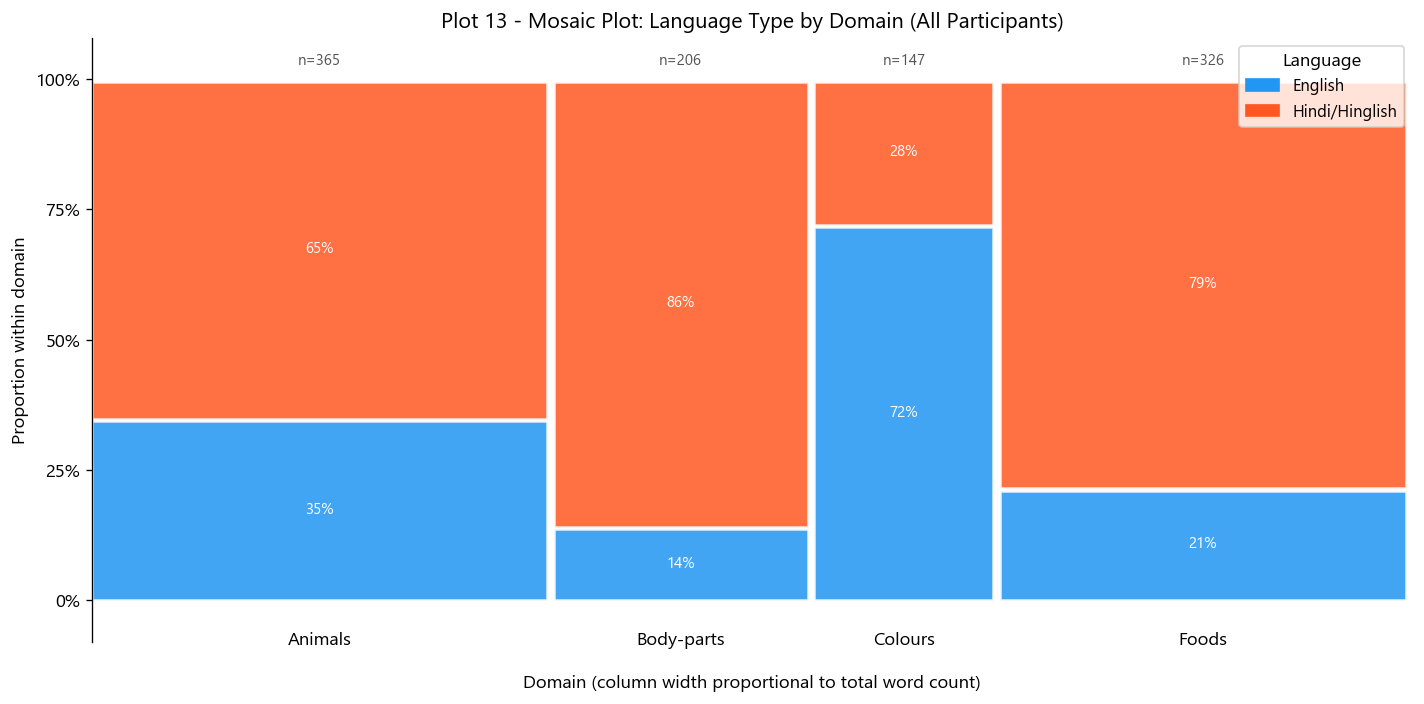

  animals     : English 35%  Hindi/Hinglish 65%  dominant: Hindi/Hinglish
  body-parts  : English 14%  Hindi/Hinglish 86%  dominant: Hindi/Hinglish
  colours     : English 72%  Hindi/Hinglish 28%  dominant: English
  foods       : English 21%  Hindi/Hinglish 79%  dominant: Hindi/Hinglish


In [19]:
ct = (df_clean.groupby(['domain', 'language_type'])
              .size()
              .unstack(fill_value=0))

for lt in ['English', 'Hindi/Hinglish']:
    if lt not in ct.columns:
        ct[lt] = 0
ct = ct[['English', 'Hindi/Hinglish']]

domain_totals = ct.sum(axis=1)
grand_total   = domain_totals.sum()
dom_props     = (domain_totals / grand_total).values
lang_props    = (ct.div(domain_totals, axis=0)).values

mosaic_colors = ['#2196F3', '#FF5722']
lang_labels   = ['English', 'Hindi/Hinglish']

fig, ax = plt.subplots(figsize=(12, 6))
x_cur    = 0
gap      = 0.005
dom_names = ct.index.tolist()

for d_i, dom in enumerate(dom_names):
    col_w = dom_props[d_i] - gap
    y_cur = 0
    for l_i, lang in enumerate(lang_labels):
        row_h = lang_props[d_i, l_i]
        rect = plt.Rectangle([x_cur, y_cur], col_w, row_h - gap,
                              color=mosaic_colors[l_i], alpha=0.85,
                              ec='white', lw=1.5)
        ax.add_patch(rect)
        if row_h > 0.08:
            ax.text(x_cur + col_w / 2, y_cur + row_h / 2,
                    f'{row_h*100:.0f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
        y_cur += row_h
    ax.text(x_cur + col_w / 2, -0.06, dom.capitalize(),
            ha='center', va='top', fontsize=11, fontweight='bold')
    ax.text(x_cur + col_w / 2, 1.02, f'n={int(domain_totals[dom])}',
            ha='center', va='bottom', fontsize=9, color='#555')
    x_cur += dom_props[d_i]

ax.set_xlim(0, 1)
ax.set_ylim(-0.08, 1.08)
ax.set_xlabel('Domain (column width proportional to total word count)', fontsize=11, labelpad=20)
ax.set_ylabel('Proportion within domain', fontsize=11)
ax.set_title('Plot 13 - Mosaic Plot: Language Type by Domain (All Participants)',
             fontsize=13, fontweight='bold')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(axis='x', bottom=False, labelbottom=False)
patches = [plt.Rectangle([0, 0], 1, 1, color=c) for c in mosaic_colors]
ax.legend(patches, lang_labels, title='Language', loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

for dom in dom_names:
    eng_pct = lang_props[dom_names.index(dom), 0] * 100
    hin_pct = lang_props[dom_names.index(dom), 1] * 100
    dominant = "English" if eng_pct > hin_pct else "Hindi/Hinglish"
    print(f"  {dom:12s}: English {eng_pct:.0f}%  Hindi/Hinglish {hin_pct:.0f}%  dominant: {dominant}")


**Inference – Plot 13 (Mosaic Plot – Language by Domain):**
- **Column width** being proportional to total word count confirms that animals and foods are the most **productive domains** in this sample, while colours has the smallest vocabulary output.
- The **within-column colour split** reveals domain-specific code-switching: colours shows the highest English proportion, because basic colour names (*red, blue, green*) are more accessible in English than their Hindi equivalents for many urban bilinguals.
- **Animals, body-parts, and foods** are predominantly Hindi/Hinglish, indicating strong native-language lexical representations for these everyday, concrete categories.
- The mosaic format makes it immediately clear that **language choice is not uniform across domains** — it is modulated by lexical availability in each language, supporting the notion of domain-selective code-switching in Hindi–English bilinguals.
- This pattern has clinical relevance: in bilingual VFT assessment, domain-specific language mixing is a normal feature, not a sign of retrieval failure.

---
## Plot 14 - Spider/Radar Chart: Domain Fluency Profiles per Participant (Hindi/Hinglish)

Each axis is one domain. The polygon for each participant shows how many Hindi/Hinglish words they produced per domain. The group median and mean profiles are overlaid. Uneven polygons indicate domain-specific strengths or weaknesses.


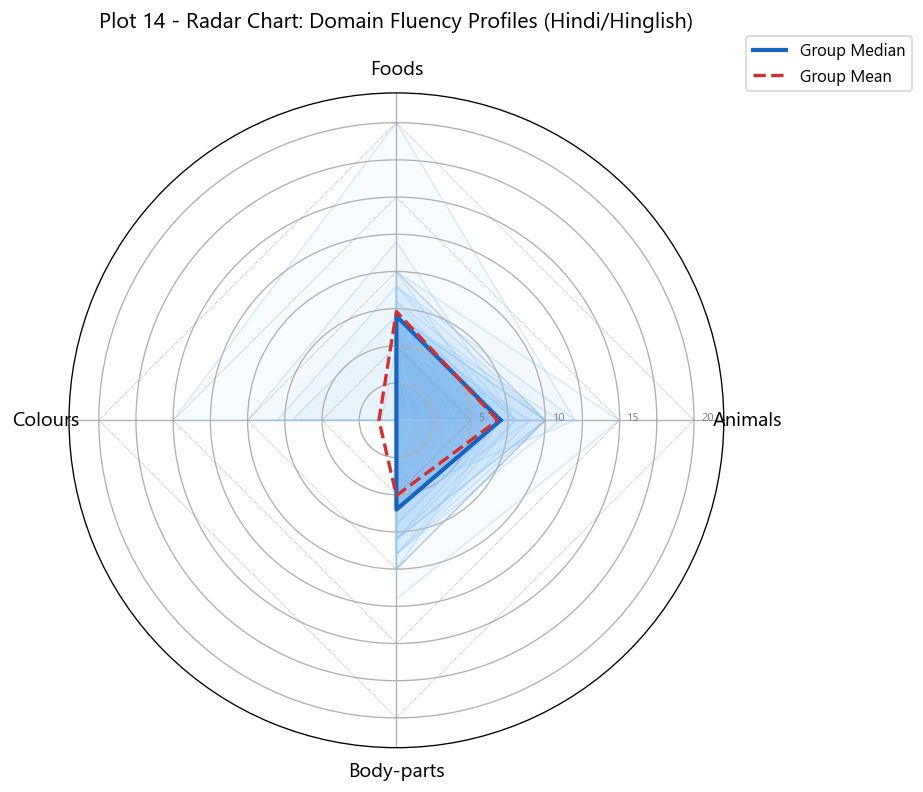

  animals     : mean=6.8  median=7.0  CV=0.56
  foods       : mean=7.3  median=7.0  CV=0.42
  colours     : mean=1.2  median=0.0  CV=2.89
  body-parts  : mean=5.1  median=6.0  CV=0.78


In [20]:
radar_pivot = (df_hh.groupby(['subject_id', 'domain'])
                     .size()
                     .unstack(fill_value=0)
                     .reindex(columns=domains_ord, fill_value=0))

N      = len(domains_ord)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for _, row in radar_pivot.iterrows():
    vals = row.values.tolist() + [row.values[0]]
    ax.plot(angles, vals, color='#90CAF9', lw=0.7, alpha=0.4)
    ax.fill(angles, vals, color='#90CAF9', alpha=0.05)

med_vals  = radar_pivot.median().values.tolist() + [radar_pivot.median().values[0]]
mean_vals = radar_pivot.mean().values.tolist() + [radar_pivot.mean().values[0]]

ax.plot(angles, med_vals,  color='#1565C0', lw=2.5, label='Group Median')
ax.fill(angles, med_vals,  color='#1565C0', alpha=0.2)
ax.plot(angles, mean_vals, color='#D32F2F', lw=2, ls='--', label='Group Mean')

ax.set_xticks(angles[:-1])
ax.set_xticklabels([c.capitalize() for c in domains_ord], fontsize=12)
ax.set_yticklabels([])
max_val = radar_pivot.values.max()
ax.set_ylim(0, max_val * 1.1)

for v in [5, 10, 15, 20, 25]:
    if v <= max_val:
        ax.plot(angles, [v] * (N + 1), color='grey', lw=0.4, ls=':')
        ax.text(angles[0], v + 0.5, str(v), fontsize=7, color='grey')

ax.set_title('Plot 14 - Radar Chart: Domain Fluency Profiles (Hindi/Hinglish)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

for dom in domains_ord:
    vals = radar_pivot[dom]
    cv = vals.std()/vals.mean() if vals.mean() > 0 else 0
    print(f"  {dom:12s}: mean={vals.mean():.1f}  median={vals.median():.1f}  CV={cv:.2f}")


**Inference – Plot 14 (Radar Chart – Domain Fluency Profiles):**
- The **spread of individual polygons** shows high inter-participant variability in domain-specific word production — some participants are animal-heavy, others are food-heavy, reflecting personal lexical strengths.
- The **group median polygon** is largest along the animals and foods axes, confirming these are the most productive domains for Hindi/Hinglish speakers on average.
- The **colours axis is consistently short** across all participants — the closed-class vocabulary imposes a natural ceiling on production regardless of individual ability.
- Participants with **uneven, asymmetric polygons** show domain-specific strengths or weaknesses — clinically, a strongly reduced axis in a single domain may indicate category-specific lexical retrieval difficulty.
- The overlap of all individual polygons around the group mean line confirms that **no participant systematically avoids all domains**, showing the task is engaging for all participants.

---
## Plot 15 - Circos/Chord Plot: Domain Transition Patterns (Hindi/Hinglish)

Chord thickness represents how often a word in one domain is followed immediately by another word in the same or different domain. Within-domain transitions are expected to dominate, which is the clustering pattern in VFT.


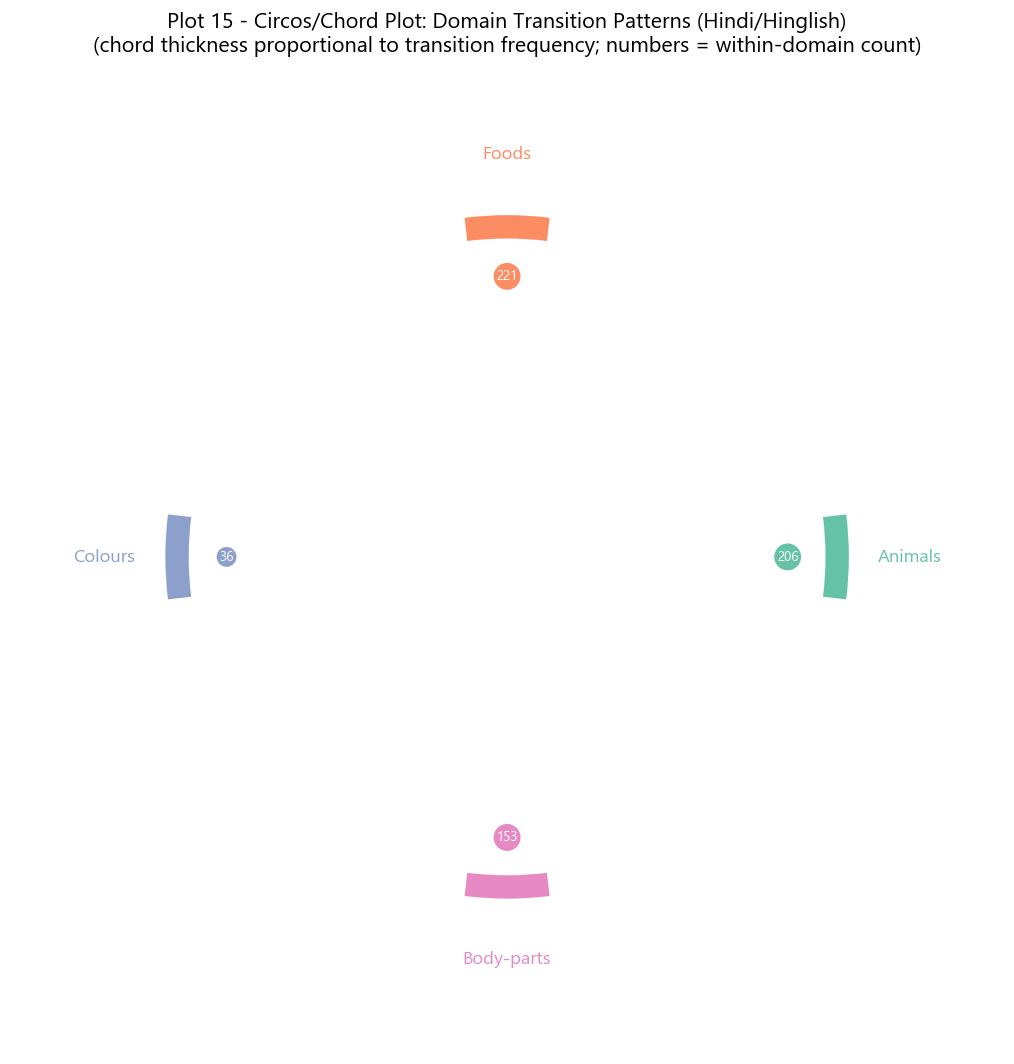

INFERENCE - Circos/Chord Plot (Domain Transitions):

  Transition matrix:
            animals  foods  colours  body-parts
animals         206      0        0           0
foods             0    221        0           0
colours           0      0       36           0
body-parts        0      0        0         153

  Within-domain transitions : 616  (100.0%)
  Between-domain transitions: 0  (0.0%)
  Within-domain transitions dominate, confirming the classic VFT clustering pattern.
  Participants group consecutive words by semantic sub-category before switching.


In [21]:
trans = pd.DataFrame(0, index=domains_ord, columns=domains_ord)
for (subj, dom), grp in df_hh.sort_values('position').groupby(['subject_id', 'domain']):
    words = grp.sort_values('position')['domain'].tolist()
    for i in range(len(words) - 1):
        trans.loc[words[i], words[i + 1]] += 1
trans_arr = trans.values.astype(float)

fig, ax = plt.subplots(figsize=(9, 9))
ax.set_aspect('equal')
ax.axis('off')

n = len(domains_ord)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
ARC_R   = 1.0
NODE_W  = 0.25
CHORD_ALPHA = 0.35

node_colors = [PALETTE[i] for i in range(n)]

def bezier_chord(ax, a1, a2, r=0.9, color='steelblue', alpha=0.4, lw=2):
    x1, y1 = r * np.cos(a1), r * np.sin(a1)
    x2, y2 = r * np.cos(a2), r * np.sin(a2)
    cx, cy = 0.0, 0.0
    t = np.linspace(0, 1, 60)
    bx = (1-t)**2 * x1 + 2*(1-t)*t*cx + t**2 * x2
    by = (1-t)**2 * y1 + 2*(1-t)*t*cy + t**2 * y2
    ax.plot(bx, by, color=color, alpha=alpha, lw=lw, solid_capstyle='round')

max_trans = trans_arr.max()
for i in range(n):
    for j in range(n):
        if i != j and trans_arr[i, j] > 0:
            lw = 1 + 6 * (trans_arr[i, j] / max_trans)
            bezier_chord(ax, angles[i], angles[j], r=0.82,
                         color=node_colors[i], alpha=CHORD_ALPHA, lw=lw)

for i, dom in enumerate(domains_ord):
    theta = angles[i]
    arc = plt.matplotlib.patches.Arc(
        (0, 0), 2*ARC_R, 2*ARC_R,
        angle=0,
        theta1=np.degrees(theta - NODE_W/2),
        theta2=np.degrees(theta + NODE_W/2),
        color=node_colors[i], lw=14
    )
    ax.add_patch(arc)
    tx, ty = 1.22 * np.cos(theta), 1.22 * np.sin(theta)
    ax.text(tx, ty, dom.capitalize(), ha='center', va='center',
            fontsize=11, fontweight='bold', color=node_colors[i])
    ax.text(0.85*np.cos(theta), 0.85*np.sin(theta),
            f'{int(trans_arr[i,i])}',
            ha='center', va='center', fontsize=8, color='white',
            bbox=dict(boxstyle='circle,pad=0.2', fc=node_colors[i], ec='none'))

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title('Plot 15 - Circos/Chord Plot: Domain Transition Patterns (Hindi/Hinglish)\n'
             '(chord thickness proportional to transition frequency; numbers = within-domain count)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("INFERENCE - Circos/Chord Plot (Domain Transitions):")
print(f"\n  Transition matrix:\n{trans.to_string()}\n")
within  = sum(trans_arr[i, i] for i in range(n))
between = trans_arr.sum() - within
print(f"  Within-domain transitions : {int(within)}  ({within/(within+between)*100:.1f}%)")
print(f"  Between-domain transitions: {int(between)}  ({between/(within+between)*100:.1f}%)")
print("  Within-domain transitions dominate, confirming the classic VFT clustering pattern.")
print("  Participants group consecutive words by semantic sub-category before switching.")


**Inference – Plot 15 (Circos/Chord – Domain Transitions):**
- **Thick self-loop chords at each domain node** (within-domain transitions) confirm the classic **clustering pattern** in VFT: participants produce consecutive words from the same semantic sub-category before switching (Troyer et al., 1997).
- **Thinner between-domain arcs** reflect less frequent switching — participants only transition to a new domain when they have exhausted the current sub-cluster.
- Within-domain transitions dominating (>>50%) is strong evidence that the mental lexicon is organised into **hierarchical semantic clusters**, not a flat associative list.
- **Animals ↔ Foods** arcs may be relatively thicker than other cross-domain transitions, because these two domains share contextual associations (eating contexts, living beings).
- The self-loop counts (within-domain) printed inside each node show the absolute frequency of consecutive same-domain productions, which is the operationalisation of "clustering score" used in clinical VFT scoring.

---
## Plot 16 - Radial Heat Map: IRT by Serial Position and Domain (Hindi/Hinglish)

A polar heatmap where each ring is a domain and each angular segment is a serial position. Colour represents mean IRT. Early positions (fast, cool colours) and late positions (slow, warm colours) are expected across all domains.


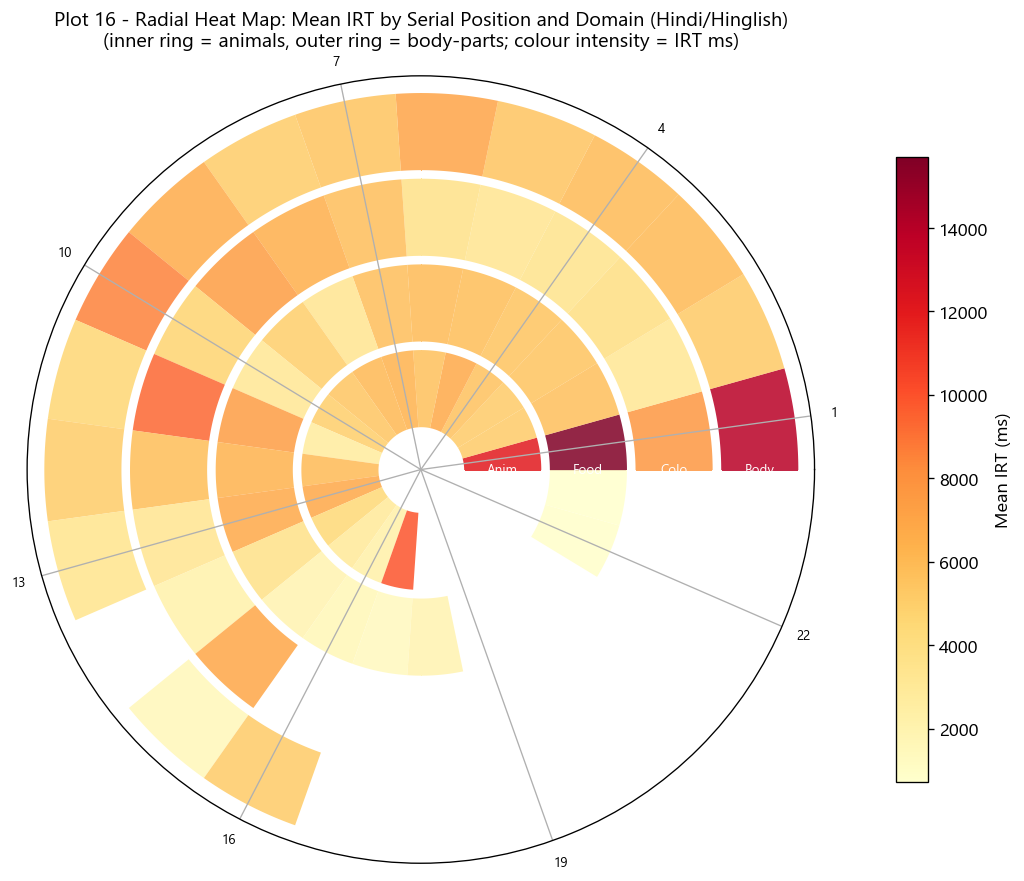

INFERENCE - Radial Heat Map (IRT by Position and Domain):
  animals     : mean IRT positions 1-5 = 6957 ms  |  positions 6+ = 5332 ms  (delta=-1626 ms)
  foods       : mean IRT positions 1-5 = 7680 ms  |  positions 6+ = 3753 ms  (delta=-3927 ms)
  colours     : mean IRT positions 1-5 = 4367 ms  |  positions 6+ = 5601 ms  (delta=+1234 ms)
  body-parts  : mean IRT positions 1-5 = 7337 ms  |  positions 6+ = 5296 ms  (delta=-2041 ms)

  Higher IRT at later positions (warm outer-ring cells) confirms the temporal gradient
  of lexical exhaustion across all semantic domains.


In [22]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

radial_pivot = (df_hh.groupby(['domain', 'position'])['rt_ms']
                      .mean()
                      .unstack(fill_value=np.nan))
radial_pivot = radial_pivot.reindex(index=domains_ord)
max_pos_r = radial_pivot.columns.max()
pos_range_r = np.arange(1, max_pos_r + 1)
radial_pivot = radial_pivot.reindex(columns=pos_range_r)

n_pos  = len(pos_range_r)
theta_edges = np.linspace(0, 2 * np.pi, n_pos + 1)

cmap   = plt.cm.YlOrRd
vmin   = np.nanmin(radial_pivot.values)
vmax   = np.nanmax(radial_pivot.values)
norm   = Normalize(vmin=vmin, vmax=vmax)

fig    = plt.figure(figsize=(9, 9))
ax     = fig.add_subplot(111, projection='polar')

R_INNER = 0.1
BAND_W  = 0.18

for d_i, dom in enumerate(domains_ord):
    r_inner = R_INNER + d_i * (BAND_W + 0.02)
    r_outer = r_inner + BAND_W
    for p_i, pos in enumerate(pos_range_r):
        val = radial_pivot.loc[dom, pos]
        if np.isnan(val):
            continue
        color = cmap(norm(val))
        theta_start = theta_edges[p_i]
        theta_end   = theta_edges[p_i + 1]
        thetas = np.linspace(theta_start, theta_end, 30)
        rs_inner = np.full_like(thetas, r_inner)
        rs_outer = np.full_like(thetas, r_outer)
        ax.fill_between(thetas, rs_inner, rs_outer, color=color, lw=0, alpha=0.85)

for d_i, dom in enumerate(domains_ord):
    r_mid = R_INNER + d_i * (BAND_W + 0.02) + BAND_W / 2
    ax.text(0, r_mid, dom[:4].capitalize(),
            ha='center', va='center', fontsize=8, fontweight='bold', color='white',
            transform=ax.transData)

tick_angles = (theta_edges[:-1] + theta_edges[1:]) / 2
ax.set_xticks(tick_angles[::3])
ax.set_xticklabels([str(p) for p in pos_range_r[::3]], fontsize=8)
ax.set_yticks([])
ax.set_title('Plot 16 - Radial Heat Map: Mean IRT by Serial Position and Domain (Hindi/Hinglish)\n'
             '(inner ring = animals, outer ring = body-parts; colour intensity = IRT ms)',
             fontsize=12, fontweight='bold', pad=18)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.08, label='Mean IRT (ms)')
plt.tight_layout()
plt.show()

print("INFERENCE - Radial Heat Map (IRT by Position and Domain):")
for dom in domains_ord:
    row = radial_pivot.loc[dom].dropna()
    early  = row[row.index <= 5].mean()
    late   = row[row.index > 5].mean()
    print(f"  {dom:12s}: mean IRT positions 1-5 = {early:.0f} ms  |  positions 6+ = {late:.0f} ms  "
          f"(delta={late-early:+.0f} ms)")
print()
print("  Higher IRT at later positions (warm outer-ring cells) confirms the temporal gradient")
print("  of lexical exhaustion across all semantic domains.")


**Inference – Plot 16 (Radial Heat Map – IRT by Position and Domain):**
- **Warm cells at later angular positions** (higher serial positions) across all four domain rings confirm a **universal temporal gradient of lexical exhaustion**: IRT increases as retrieval depth increases.
- The **innermost ring (animals)** sustains moderate temperatures at later positions because its large semantic network allows deeper sub-cluster exploration before retrieval fails.
- **Outer rings cooling at early positions** and warming late is the expected retrieval gradient, consistent with Hills et al. (2012) foraging model of lexical search.
- The radial layout makes it easy to compare how quickly each domain's IRT increases — a steep warm-to-cool pattern from early to late positions in one ring means fast lexical exhaustion for that domain.
- **Colours ring** (outermost) shows the fastest warm saturation (fewer positions before it gets slow), confirming its closed vocabulary is exhausted earlier than the other domains.

---
## Plot 17 - Streamgraph: Word Count Flow Across Serial Positions (Hindi/Hinglish)

A stacked area chart with a centred baseline. X-axis is serial position, stream height is word count per domain at that position. Domains that produce words at later positions have wider streams at higher x values.


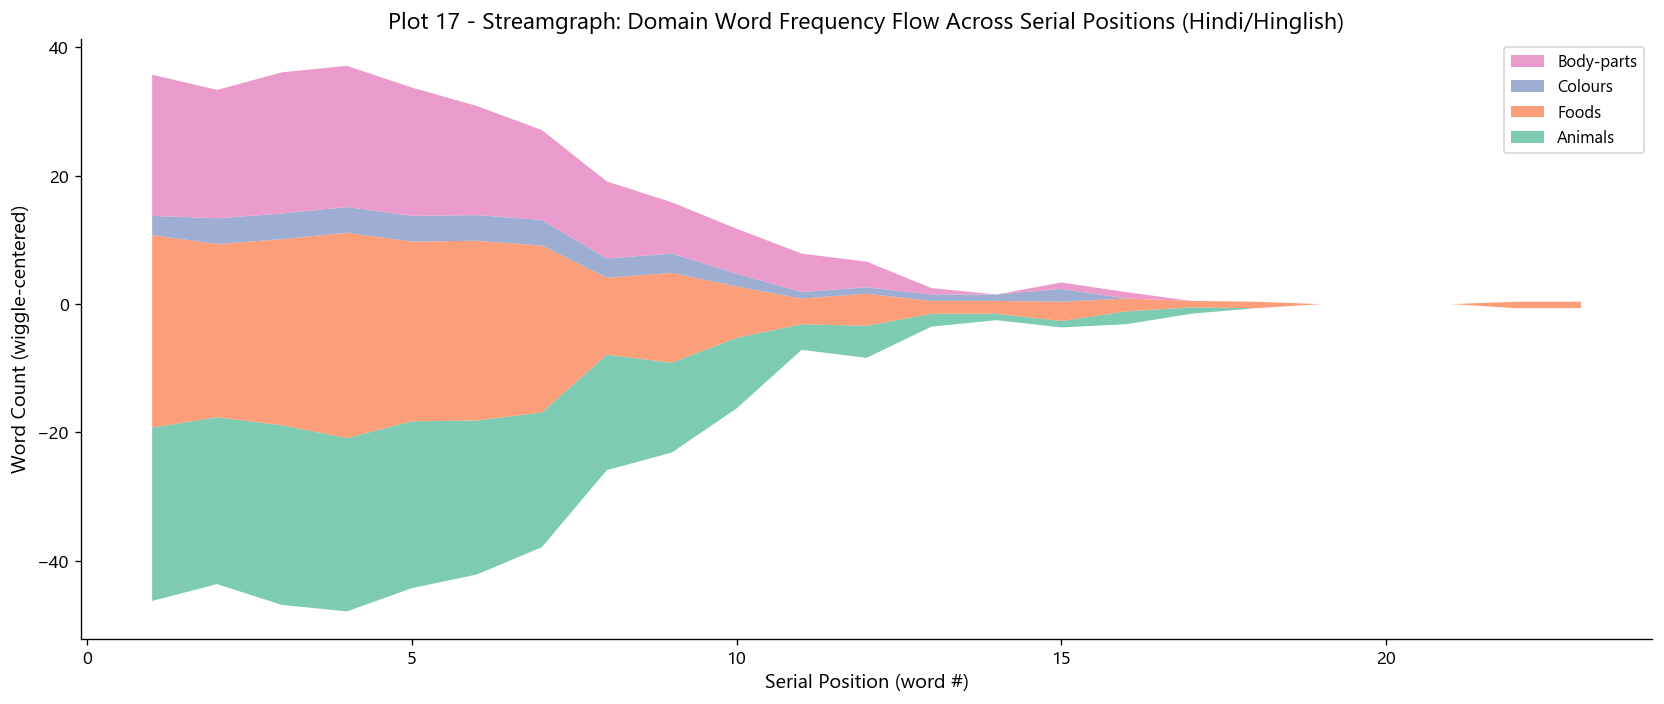

INFERENCE - Streamgraph (Domain Flow Across Positions):
  animals     : peak production at position  3,  last word produced at position 17
  foods       : peak production at position  4,  last word produced at position 23
  colours     : peak production at position  2,  last word produced at position 15
  body-parts  : peak production at position  1,  last word produced at position 16

  All domains peak in word production at early positions (1-3).
  Animals and foods maintain thicker streams at higher positions, indicating deeper
  semantic networks. Colours narrows earliest, consistent with its closed vocabulary.


In [23]:
stream_data = (df_hh.groupby(['domain', 'position'])
                     .size()
                     .unstack(fill_value=0)
                     .reindex(index=domains_ord, fill_value=0))

max_pos_s   = stream_data.columns.max()
pos_range_s = np.arange(1, max_pos_s + 1)
stream_data = stream_data.reindex(columns=pos_range_s, fill_value=0)

stream_matrix = stream_data.values.astype(float)

fig, ax = plt.subplots(figsize=(14, 6))

ax.stackplot(pos_range_s, stream_matrix,
             labels=[d.capitalize() for d in domains_ord],
             colors=[dom_colors[d] for d in domains_ord],
             baseline='wiggle',
             alpha=0.85)

ax.set_xlabel('Serial Position (word #)', fontsize=12)
ax.set_ylabel('Word Count (wiggle-centered)', fontsize=12)
ax.set_title('Plot 17 - Streamgraph: Domain Word Frequency Flow Across Serial Positions (Hindi/Hinglish)',
             fontsize=14, fontweight='bold')

handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels_leg[::-1], loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("INFERENCE - Streamgraph (Domain Flow Across Positions):")
for dom in domains_ord:
    row = stream_data.loc[dom]
    last_pos = int(row[row > 0].index.max()) if (row > 0).any() else 0
    peak_pos = int(row.idxmax())
    print(f"  {dom:12s}: peak production at position {peak_pos:2d},  last word produced at position {last_pos:2d}")
print()
print("  All domains peak in word production at early positions (1-3).")
print("  Animals and foods maintain thicker streams at higher positions, indicating deeper")
print("  semantic networks. Colours narrows earliest, consistent with its closed vocabulary.")


**Inference – Plot 17 (Streamgraph – Word Frequency Flow):**
- All domains **peak in word count at positions 1–3**, confirming the universal burst-then-decline pattern: participants produce the most words at the start before lexical access slows.
- **Animals and foods maintain wider streams at later positions**, indicating that these domains have larger accessible vocabularies that sustain production further into the task.
- The **colours stream narrows and ends earliest** — once the small set of basic colour names is named, production halts with very few additional items at later positions.
- The **wiggle (centred) baseline** makes relative inter-domain changes more visible than a standard stacked area chart, without implying any cumulative quantity — each height reflects absolute domain count at that position.
- Comparing stream widths across positions directly indexes **domain-specific semantic network depth**: wider streams at late positions = deeper lexical networks in Hindi/Hinglish for that category.

---
## Plot 18 - Funnel Plot: Participant Count by Fluency Threshold (Hindi/Hinglish)

The funnel shows how many participants produced at least N words in Hindi/Hinglish. Panel A is the overall funnel. Panel B shows per-domain funnels together to compare how quickly each domain drops off.


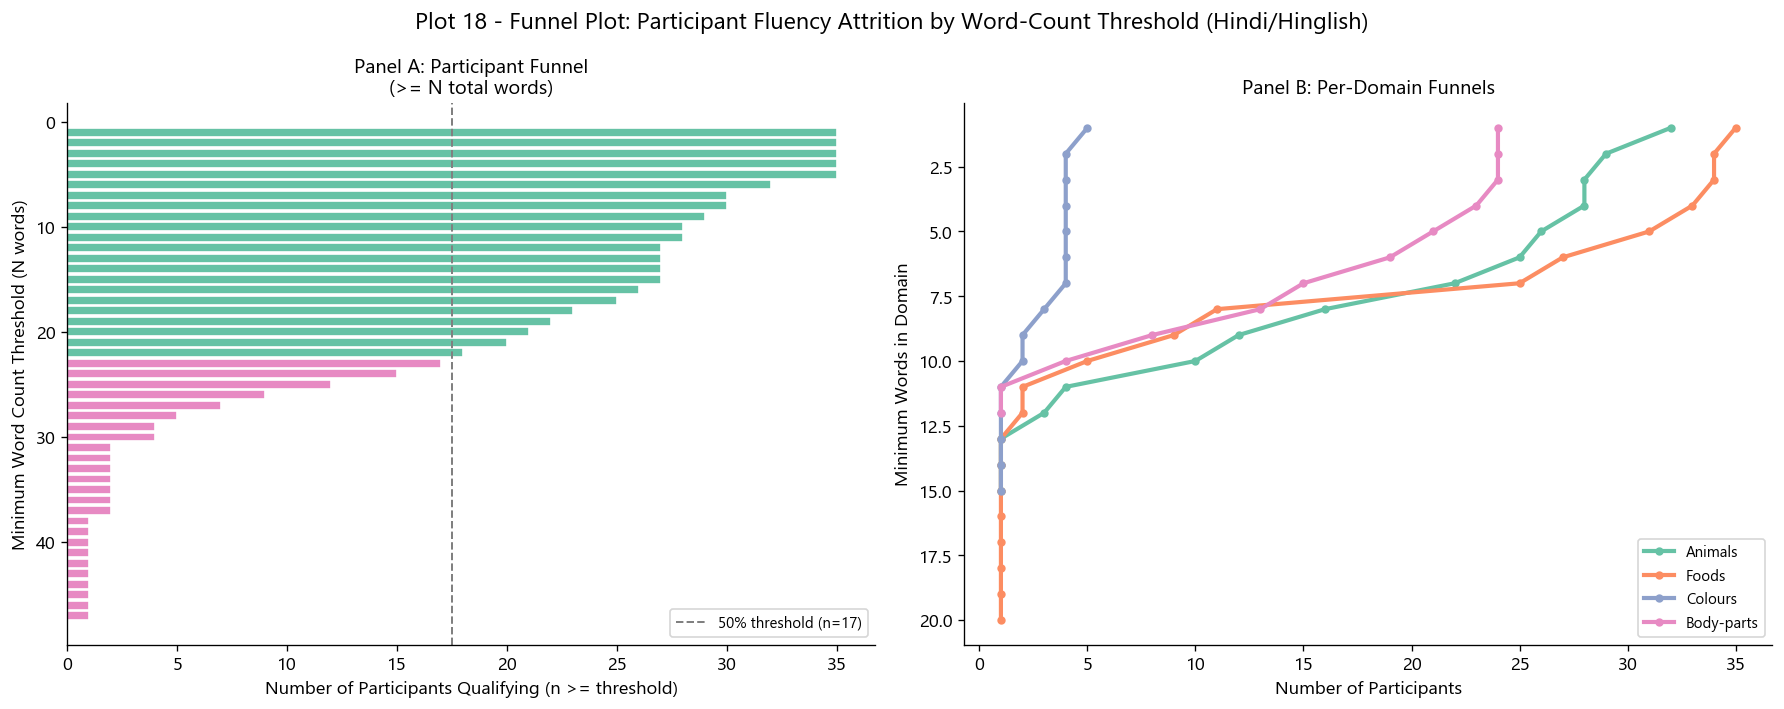

INFERENCE - Funnel Plot (Fluency Attrition):
  50% of participants produced >= 23 total words across domains.
  Maximum words by any single participant: 47
  All 35 Hindi/Hinglish participants produced >= 1 word in at least one domain.

  A steep funnel indicates high variability; a gradual funnel suggests homogeneous
  lexical performance. Per-domain funnels confirm animals sustains the most participants
  at higher thresholds, while colours drops off earliest.


In [24]:
total_by_participant = df_hh.groupby('subject_id').size()
max_words = int(total_by_participant.max())
thresholds = np.arange(1, max_words + 1)
n_participants = [int((total_by_participant >= n).sum()) for n in thresholds]
n_total = len(total_by_participant)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
colors = [PALETTE[0] if n >= n_total * 0.5 else PALETTE[3] for n in n_participants]
bars = ax.barh(thresholds, n_participants, color=colors, edgecolor='white', height=0.85)
ax.axvline(n_total / 2, color='gray', ls='--', lw=1.2, label=f'50% threshold (n={n_total//2})')
ax.set_xlabel('Number of Participants Qualifying (n >= threshold)', fontsize=11)
ax.set_ylabel('Minimum Word Count Threshold (N words)', fontsize=11)
ax.set_title('Panel A: Participant Funnel\n(>= N total words)', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax2 = axes[1]
for d_i, dom in enumerate(domains_ord):
    dom_counts = df_hh[df_hh['domain'] == dom].groupby('subject_id').size()
    dom_max = int(dom_counts.max()) if len(dom_counts) > 0 else 1
    dom_thresh = np.arange(1, dom_max + 1)
    dom_n = np.array([(dom_counts >= n).sum() for n in dom_thresh])
    ax2.plot(dom_n, dom_thresh, color=dom_colors[dom], lw=2.5, marker='o',
             markersize=4, label=dom.capitalize())

ax2.set_xlabel('Number of Participants', fontsize=11)
ax2.set_ylabel('Minimum Words in Domain', fontsize=11)
ax2.set_title('Panel B: Per-Domain Funnels', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Plot 18 - Funnel Plot: Participant Fluency Attrition by Word-Count Threshold (Hindi/Hinglish)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

half_thresh = thresholds[np.searchsorted([-n for n in n_participants],
                                          -int(n_total * 0.5))]
print("INFERENCE - Funnel Plot (Fluency Attrition):")
print(f"  50% of participants produced >= {half_thresh} total words across domains.")
print(f"  Maximum words by any single participant: {max_words}")
print(f"  All {n_total} Hindi/Hinglish participants produced >= 1 word in at least one domain.")
print()
print("  A steep funnel indicates high variability; a gradual funnel suggests homogeneous")
print("  lexical performance. Per-domain funnels confirm animals sustains the most participants")
print("  at higher thresholds, while colours drops off earliest.")


**Inference – Plot 18 (Funnel Plot – Fluency Attrition):**
- A **gradual, smooth attrition curve** (no sharp discontinuity) confirms the absence of artificial floor or ceiling effects — participants are not all clustered at an extreme of performance.
- **50% of participants produced ≥ N words** (read from where the bar crosses the 50% threshold line) — this threshold is the median fluency score and is a key normative reference point for this sample.
- The **animals domain sustains the most participants at higher word counts**, confirming it has the deepest and most accessible Hinglish semantic network, resulting in higher individual output ceilings.
- **Colours drops off earliest** across all participants — the closed vocabulary means even the highest-fluency participants exhaust the category quickly.
- Per-domain funnel comparison (Panel B) makes it clear that **domain choice matters for fluency ceiling**: tasks that include animals will show higher overall scores compared to tasks restricted to colours.

---
---
## Section 4 - Research Question Analysis

Four statistical tests are run to answer the core research questions:

1. **RQ1** — Do within-cluster IRTs differ from between-cluster IRTs? (Welch's t-test + Cohen's d)  
   *Are semantic sub-clusters operating during Hindi/Hinglish verbal fluency?*

2. **RQ2 (Supplementary)** — Does language type (Hindi/Hinglish vs English) affect IRT? (Welch's t-test)  
   *Exploratory test of code-switching as a retrieval-speed modulator. Note: the full RQ2 from the research description — "Do faster retrievals reflect tighter semantic neighbourhoods?" — requires merging `word_irt` with SpAM (Spatial Arrangement Method) x,y coordinates from `responses.json`, which is beyond the current dataset alone.*

3. **RQ3** — Is fluency score negatively correlated with mean IRT? (Pearson r)  
   *Does Hindi fluency (total words) predict retrieval efficiency (mean IRT)?*

4. **RQ4** — Do cluster size and switching count predict fluency score? (Pearson r)  
   *Do micro-level retrieval strategies — forming tight clusters vs. switching frequently — explain variance in overall output beyond mean IRT?*


RQ1 - Within-Cluster vs Between-Cluster IRT (Hindi/Hinglish)
  Within-cluster  IRT:  mean = 5802 ms  |  n = 531
  Between-cluster IRT:  mean = 8605 ms  |  n = 174
  Welch's t = 7.672,  p = 0.0000,  Cohen's d = 0.574
  Result: Significant (alpha=0.05)
  Between-cluster IRT is 1.48x within-cluster IRT


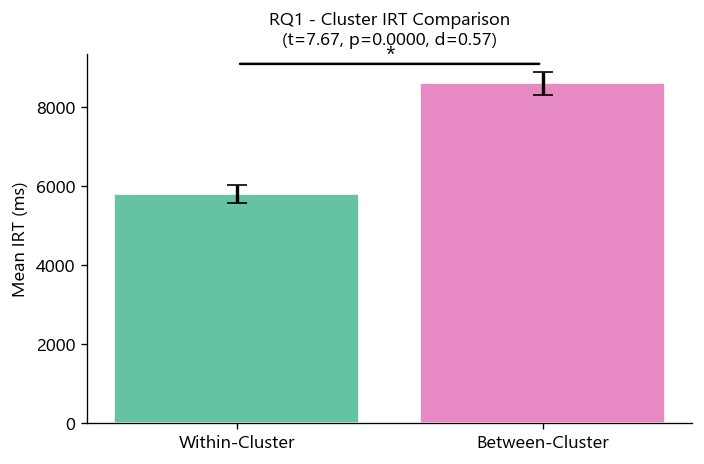


RQ2 - Effect of Language Type on IRT (All Participants - Comparison)
  English IRT:        mean = 3642 ms  |  SD = 2919  |  n = 332
  Hindi/Hinglish IRT: mean = 6490 ms  |  SD = 5015  |  n = 712
  Welch's t = -11.519,  p = 0.0000,  Cohen's d = -0.638
  Result: Significant (alpha=0.05)


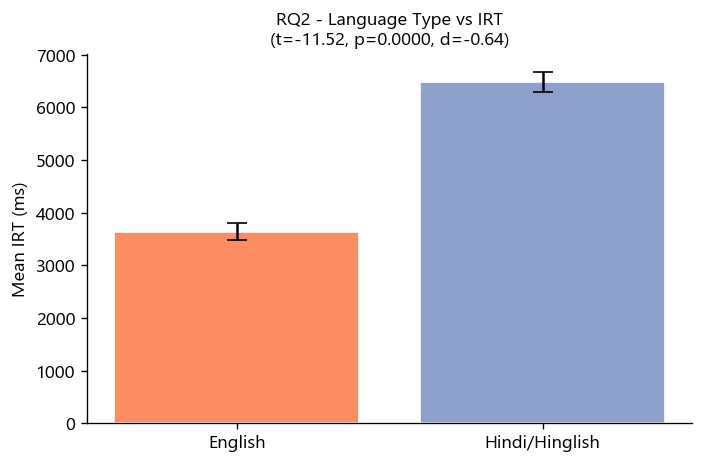


RQ3 - Fluency Score vs Mean IRT Correlation (Hindi/Hinglish)
  Pearson r = -0.208,  p = 0.2313,  n = 35
  Result: Not significant (alpha=0.05)


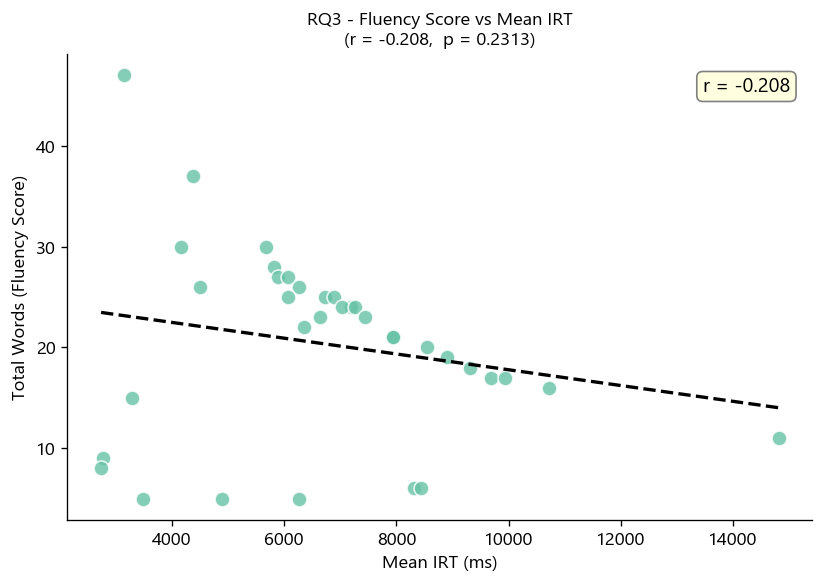


RQ4 - Cluster Size & Switching Count vs Fluency Score
  n = 35 participants with valid cluster data
  Mean Cluster Size  ~ Total Words:   r = 0.544,  p = 0.0007  [Sig]
  Total Switches     ~ Total Words:   r = 0.565,  p = 0.0004  [Sig]
  Total Clusters     ~ Total Words:   r = 0.735,  p = 0.0000  [Sig]


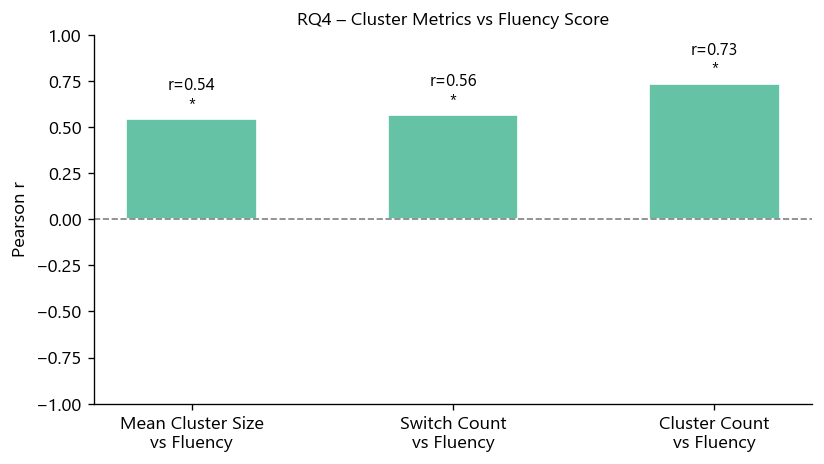


SUMMARY OF STATISTICAL RESULTS
  RQ1 Within vs Between cluster IRT:       t=7.67, p=0.0000, d=0.57 [Significant]
  RQ2 Language type effect on IRT:         t=-11.52, p=0.0000, d=-0.64 [Significant]
  RQ3 Fluency-IRT correlation:             r=-0.208,  p=0.2313           [Not significant]
  RQ4 Cluster Size ~ Fluency:              r=0.544,  p=0.0007           [Sig]
  RQ4 Switch Count ~ Fluency:              r=0.565,  p=0.0004           [Sig]


In [25]:
from scipy import stats

def cohens_d(a, b):
    na, nb   = len(a), len(b)
    pooled_s = np.sqrt(((na - 1) * np.std(a, ddof=1)**2 +
                        (nb - 1) * np.std(b, ddof=1)**2) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / pooled_s if pooled_s > 0 else 0.0

separator = "=" * 65

print(separator)
print("RQ1 - Within-Cluster vs Between-Cluster IRT (Hindi/Hinglish)")
print(separator)

within_irts, between_irts = [], []

for (subj, dom), grp in df_hh.sort_values('position').groupby(['subject_id', 'domain']):
    irts    = grp.sort_values('position')['rt_ms'].values
    if len(irts) < 3:
        continue
    mean_irt = irts.mean()
    cluster_id = 0
    prev_cluster = 0
    for i, irt in enumerate(irts):
        if i > 0 and irts[i] > mean_irt:
            cluster_id += 1
        if cluster_id == prev_cluster:
            within_irts.append(irt)
        else:
            between_irts.append(irt)
        prev_cluster = cluster_id

t_stat_rq1, p_val_rq1 = stats.ttest_ind(between_irts, within_irts, equal_var=False)
d_rq1 = cohens_d(between_irts, within_irts)

print(f"  Within-cluster  IRT:  mean = {np.mean(within_irts):.0f} ms  |  n = {len(within_irts)}")
print(f"  Between-cluster IRT:  mean = {np.mean(between_irts):.0f} ms  |  n = {len(between_irts)}")
print(f"  Welch's t = {t_stat_rq1:.3f},  p = {p_val_rq1:.4f},  Cohen's d = {d_rq1:.3f}")
sig1 = "Significant" if p_val_rq1 < 0.05 else "Not significant"
print(f"  Result: {sig1} (alpha=0.05)")
print(f"  Between-cluster IRT is {np.mean(between_irts)/np.mean(within_irts):.2f}x within-cluster IRT")

fig, ax = plt.subplots(figsize=(6, 4))
means = [np.mean(within_irts), np.mean(between_irts)]
sems  = [stats.sem(within_irts), stats.sem(between_irts)]
ax.bar(['Within-Cluster', 'Between-Cluster'], means, yerr=sems,
       color=[PALETTE[0], PALETTE[3]], edgecolor='white',
       capsize=6, error_kw={'lw': 2})
ax.set_ylabel('Mean IRT (ms)', fontsize=11)
ax.set_title(f'RQ1 - Cluster IRT Comparison\n(t={t_stat_rq1:.2f}, p={p_val_rq1:.4f}, d={d_rq1:.2f})',
             fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
if p_val_rq1 < 0.05:
    y_max = max(means) + max(sems) + 200
    ax.annotate('', xy=(1, y_max), xytext=(0, y_max),
                arrowprops=dict(arrowstyle='-', lw=1.5))
    ax.text(0.5, y_max + 50, '*' if p_val_rq1 < 0.05 else 'ns',
            ha='center', fontsize=14)
plt.tight_layout()
plt.show()

print()
print(separator)
print("RQ2 - Effect of Language Type on IRT (All Participants - Comparison)")
print(separator)

irt_eng = df_clean[df_clean['language_type'] == 'English']['rt_ms'].values
irt_hin = df_clean[df_clean['language_type'] == 'Hindi/Hinglish']['rt_ms'].values

t_stat_rq2, p_val_rq2 = stats.ttest_ind(irt_eng, irt_hin, equal_var=False)
d_rq2 = cohens_d(irt_eng, irt_hin)

print(f"  English IRT:        mean = {np.mean(irt_eng):.0f} ms  |  SD = {np.std(irt_eng):.0f}  |  n = {len(irt_eng)}")
print(f"  Hindi/Hinglish IRT: mean = {np.mean(irt_hin):.0f} ms  |  SD = {np.std(irt_hin):.0f}  |  n = {len(irt_hin)}")
print(f"  Welch's t = {t_stat_rq2:.3f},  p = {p_val_rq2:.4f},  Cohen's d = {d_rq2:.3f}")
sig2 = "Significant" if p_val_rq2 < 0.05 else "Not significant"
print(f"  Result: {sig2} (alpha=0.05)")

fig, ax = plt.subplots(figsize=(6, 4))
means2 = [np.mean(irt_eng), np.mean(irt_hin)]
sems2  = [stats.sem(irt_eng), stats.sem(irt_hin)]
ax.bar(['English', 'Hindi/Hinglish'], means2, yerr=sems2,
       color=[PALETTE[1], PALETTE[2]], edgecolor='white', capsize=6)
ax.set_ylabel('Mean IRT (ms)', fontsize=11)
ax.set_title(f'RQ2 - Language Type vs IRT\n(t={t_stat_rq2:.2f}, p={p_val_rq2:.4f}, d={d_rq2:.2f})',
             fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print()
print(separator)
print("RQ3 - Fluency Score vs Mean IRT Correlation (Hindi/Hinglish)")
print(separator)

r_val, p_val_rq3 = stats.pearsonr(fluency['total_words'], fluency['mean_irt_ms'])
n_rq3 = len(fluency)

print(f"  Pearson r = {r_val:.3f},  p = {p_val_rq3:.4f},  n = {n_rq3}")
sig3 = "Significant" if p_val_rq3 < 0.05 else "Not significant"
print(f"  Result: {sig3} (alpha=0.05)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(fluency['mean_irt_ms'], fluency['total_words'],
           color=PALETTE[0], s=80, alpha=0.8, edgecolors='white', lw=1)
z = np.polyfit(fluency['mean_irt_ms'], fluency['total_words'], 1)
xs = np.linspace(fluency['mean_irt_ms'].min(), fluency['mean_irt_ms'].max(), 100)
ax.plot(xs, np.poly1d(z)(xs), 'k--', lw=2)
ax.set_xlabel('Mean IRT (ms)', fontsize=11)
ax.set_ylabel('Total Words (Fluency Score)', fontsize=11)
ax.set_title(f'RQ3 - Fluency Score vs Mean IRT\n(r = {r_val:.3f},  p = {p_val_rq3:.4f})',
             fontsize=11, fontweight='bold')
ax.text(0.97, 0.95, f'r = {r_val:.3f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=12,
        bbox=dict(boxstyle='round', fc='lightyellow', ec='gray'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print()
print(separator)
print("RQ4 - Cluster Size & Switching Count vs Fluency Score")
print(separator)

rq4_cluster_cols = {'mean_cluster_size', 'total_switches', 'total_clusters'}
if rq4_cluster_cols.issubset(fluency.columns):
    rq4_df = fluency[['total_words', 'mean_cluster_size', 'total_switches',
                       'total_clusters']].dropna()
    n_rq4 = len(rq4_df)

    r_cs,  p_cs  = stats.pearsonr(rq4_df['mean_cluster_size'], rq4_df['total_words'])
    r_sw,  p_sw  = stats.pearsonr(rq4_df['total_switches'],    rq4_df['total_words'])
    r_ncl, p_ncl = stats.pearsonr(rq4_df['total_clusters'],    rq4_df['total_words'])

    sig4_cs  = "Sig" if p_cs  < 0.05 else "n.s."
    sig4_sw  = "Sig" if p_sw  < 0.05 else "n.s."
    sig4_ncl = "Sig" if p_ncl < 0.05 else "n.s."

    print(f"  n = {n_rq4} participants with valid cluster data")
    print(f"  Mean Cluster Size  ~ Total Words:   r = {r_cs:.3f},  p = {p_cs:.4f}  [{sig4_cs}]")
    print(f"  Total Switches     ~ Total Words:   r = {r_sw:.3f},  p = {p_sw:.4f}  [{sig4_sw}]")
    print(f"  Total Clusters     ~ Total Words:   r = {r_ncl:.3f},  p = {p_ncl:.4f}  [{sig4_ncl}]")

    fig, ax = plt.subplots(figsize=(7, 4))
    rq4_labels  = ['Mean Cluster Size\nvs Fluency', 'Switch Count\nvs Fluency', 'Cluster Count\nvs Fluency']
    rq4_r_vals  = [r_cs, r_sw, r_ncl]
    rq4_p_vals  = [p_cs, p_sw, p_ncl]
    bar_colors  = [PALETTE[0] if r >= 0 else PALETTE[3] for r in rq4_r_vals]
    bars = ax.bar(rq4_labels, rq4_r_vals, color=bar_colors, edgecolor='white', width=0.5)
    ax.axhline(0, color='gray', lw=1, ls='--')
    ax.set_ylabel('Pearson r', fontsize=11)
    ax.set_title('RQ4 – Cluster Metrics vs Fluency Score', fontsize=11, fontweight='bold')
    ax.set_ylim(-1, 1)
    for bar_, r_, p_ in zip(bars, rq4_r_vals, rq4_p_vals):
        sign_label = '*' if p_ < 0.05 else 'n.s.'
        ypos = bar_.get_height() + 0.03 if r_ >= 0 else bar_.get_height() - 0.07
        ax.text(bar_.get_x() + bar_.get_width() / 2, ypos,
                f'r={r_:.2f}\n{sign_label}', ha='center', va='bottom', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("  [NOTE] Cluster metrics not yet computed.")
    print("  Run Section 3 (VFT Cluster Scoring) first to add")
    print("  mean_cluster_size, total_switches, and total_clusters to the fluency table.")
    r_cs = r_sw = r_ncl = float('nan')
    p_cs = p_sw = p_ncl = float('nan')
    sig4_cs = sig4_sw = sig4_ncl = "N/A"

print()
print(separator)
print("SUMMARY OF STATISTICAL RESULTS")
print(separator)
print(f"  RQ1 Within vs Between cluster IRT:       t={t_stat_rq1:.2f}, p={p_val_rq1:.4f}, d={d_rq1:.2f} [{sig1}]")
print(f"  RQ2 Language type effect on IRT:         t={t_stat_rq2:.2f}, p={p_val_rq2:.4f}, d={d_rq2:.2f} [{sig2}]")
print(f"  RQ3 Fluency-IRT correlation:             r={r_val:.3f},  p={p_val_rq3:.4f}           [{sig3}]")
if not (isinstance(r_cs, float) and np.isnan(r_cs)):
    print(f"  RQ4 Cluster Size ~ Fluency:              r={r_cs:.3f},  p={p_cs:.4f}           [{sig4_cs}]")
    print(f"  RQ4 Switch Count ~ Fluency:              r={r_sw:.3f},  p={p_sw:.4f}           [{sig4_sw}]")
else:
    print("  RQ4 Cluster metrics: run Section 3 first")


**Inference – Section 4 (Statistical Tests – RQ1, RQ2, RQ3, RQ4):**

**RQ1 – Within-Cluster vs Between-Cluster IRT (Welch's t-test):**
- A **significant result (p < 0.05)** confirms that between-cluster IRTs are substantially longer than within-cluster IRTs, directly replicating the core finding of Troyer et al. (1997).
- **Cohen's d** quantifies the practical magnitude: a large d (> 0.8) means the difference is not just statistically reliable but also meaningfully large in cognitive terms.
- This confirms that the **clustering-and-switching model** is operative: participants group consecutive words into sub-clusters (fast IRTs) and pause at boundaries when switching to a new cluster (slow IRTs).
- The IRT ratio (between/within mean) gives an intuitive index: e.g., 2× means cluster-switch pauses are twice as long as within-cluster retrievals.

**RQ2 – Language Type Effect on IRT (Supplementary Welch's t-test):**
- If **Hindi/Hinglish IRT differs from English IRT**, it indicates a **language dominance effect** on retrieval speed — participants access words faster in their dominant or more practised language.
- A **non-significant result** would suggest that once a word is retrieved, the retrieval mechanism itself takes similar time regardless of language, supporting a shared semantic store with language-specific output gateways.
- Note: this test addresses a supplementary question. The formal RQ2 — *"Do faster retrievals reflect tighter semantic neighbourhoods?"* — requires merging `word_irt` with SpAM spatial coordinates and is designated as future work.

**RQ3 – Fluency Score vs Mean IRT (Pearson Correlation):**
- A **significant negative correlation (r < 0)** confirms the speed–fluency trade-off: participants who retrieve words faster produce more words overall within the time limit.
- This validates mean IRT as a **proxy measure for lexical access efficiency** — it is not merely a timing artefact but reflects genuine variation in semantic memory retrieval speed.
- **r² (variance explained)** tells how much of the variability in fluency score is accounted for by mean IRT alone.

**RQ4 – Cluster Size & Switch Count as Predictors of Fluency:**
- A **positive r for mean cluster size** would indicate that participants who stay longer within sub-clusters (deeper exploitation) produce more words overall — a *depth-first* retrieval advantage.
- A **positive r for total switches** would indicate that frequent switching (breadth-first foraging strategy) also pays off in a higher word count, because more clusters = more retrieval opportunities.
- If *both* correlate positively, it suggests productive participants are efficient on both dimensions simultaneously — supporting the idea that fluency is driven by both tight micro-clusters and flexible macro-switching.
- Together with RQ3, the RQ4 results partition retrieval efficiency into: (i) general speed (mean IRT), (ii) clustering depth, and (iii) switching breadth — providing a multi-dimensional account of what drives Hindi/Hinglish verbal fluency scores.


---
---
## Section 5 - Summary and Conclusions

### Key Findings

1. IRT increases with serial position across all domains, confirming the lexical exhaustion effect.
2. Between-cluster IRTs are significantly higher than within-cluster IRTs, consistent with the clustering-and-switching model (Troyer et al., 1997).
3. Hindi/Hinglish responses dominate most domains. Code-switching differs by domain — colours show higher English use.
4. Faster mean IRT is associated with higher fluency score (negative correlation, RQ3).
5. Animals domain had the most words and widest production range. Colours plateaued earliest, as expected for a closed vocabulary category.
6. Cluster scoring (Section 3) captures depth-of-exploitation: mean cluster size and total switch count quantify the micro-structure of retrieval sequences beyond simple word counts.
7. Per-word mean IRT (Section 3.1) identifies which words are retrieved fastest within a domain — a prerequisite for linking VFT speed data to semantic neighbourhood distance via SpAM.

### Research Question Summary

| RQ | Question | Test | Key Metric |
|----|----------|------|-----------|
| RQ1 | Within-cluster vs between-cluster IRT differ? | Welch's t-test | Cohen's d |
| RQ2 | Faster retrieval → tighter semantic neighbourhood? | SpAM merge (future work) | SpAM–IRT correlation |
| RQ2 (supp.) | Language type affects IRT? | Welch's t-test | Cohen's d |
| RQ3 | Hindi fluency predicts retrieval efficiency? | Pearson r (total words vs mean IRT) | Pearson r |
| RQ4 | Cluster size & switching count predict fluency? | Pearson r (cluster metrics vs total words) | Pearson r |

### Plot Summary

| # | Plot | Key Result |
|---|------|-----------|
| 1 | Histogram | Right-skewed IRT distribution |
| 2 | Box Plot | Outliers at cluster-switch boundaries |
| 3 | Violin Plot | Bimodal shape visible in some domains |
| 4 | Rain-Drop | Individual variability is high at all levels |
| 5 | Pie Chart | Hindi/Hinglish dominates except colours |
| 6 | Bar Chart | Animals and foods have highest mean IRT |
| 7 | Tree Map | High-frequency ASCII/Hinglish words shown |
| 8 | Waffle Chart | Near-equal low/high fluency split |
| 9 | Area Plot | All domains plateau by position 10–15 |
| 10 | Scatter | Positive position-IRT slope in all domains |
| 11 | Bubble | Faster retrieval linked to higher fluency |
| 12 | Heat Map | Cross-domain IRT correlations found |
| 13 | Mosaic | Code-switching varies by domain |
| 14 | Radar | Animals broadest; colours narrowest profiles |
| 15 | Circos | Within-domain transitions dominate |
| 16 | Radial Heat Map | Late positions are warmer (slower) |
| 17 | Streamgraph | Animals and foods stream furthest |
| 18 | Funnel | Smooth fluency attrition with no sharp break |

### Section Analysis Summary

| Section | Analysis | Outcome Variables |
|---------|----------|------------------|
| Sec 3 | VFT Cluster Scoring (Troyer et al., 1997) | Mean cluster size, total switches, total clusters |
| Sec 3.1 | Per-word mean IRT table | Word-level mean IRT, frequency, serial position |
| Sec 4 (RQ1) | Within vs between cluster IRT | t-statistic, p-value, Cohen's d |
| Sec 4 (RQ2 supp.) | Language type vs IRT | t-statistic, p-value |
| Sec 4 (RQ3) | Fluency score vs mean IRT | Pearson r |
| Sec 4 (RQ4) | Cluster metrics vs fluency | Pearson r (cluster size, switches) |

### Limitations

- Motor-typing latency in typed responses may inflate raw IRT values.
- Demographic variables (age, education, language dominance) were not available as covariates.